In [1174]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sb

from sklearn.metrics import accuracy_score

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve, roc_auc_score

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import RobustScaler



In [1175]:
Train_90_path = "../Data/Train_test/train_90.csv"

Train_120_path = "../Data/Train_test/train_120.csv"

Train_150_path = "../Data/Train_test/train_150.csv"


# test


Test_90_path = "../Data/Train_test/test_90.csv"

Test_120_path = "../Data/Train_test/test_120.csv"

Test_150_path = "../Data/churn_test_dataset_150.csv"

In [1176]:
Data_train_90_df = pd.read_csv(Train_90_path)

Data_train_120_df = pd.read_csv(Train_120_path) 

Data_train_150_df = pd.read_csv(Train_150_path) 

Data_test_90_df = pd.read_csv(Test_90_path) 

Data_test_120_df = pd.read_csv(Test_120_path) 

Data_test_150_df = pd.read_csv(Test_150_path)  

-------
-------

## 90 days train_test dataset

In [1177]:
state_count = Data_train_90_df["customer_state"].value_counts()

state_count

customer_state
SP    3276
RJ    1217
MG    1048
RS     495
PR     457
SC     366
BA     301
ES     181
GO     176
PE     153
DF     151
CE     136
PA     107
MA      86
MT      79
AL      58
MS      57
PI      51
PB      51
SE      46
RN      44
TO      38
RO      31
AM      27
AC      14
RR       8
AP       8
Name: count, dtype: int64

In [1178]:
# Income
HIGH_INCOME = ["SP", "RJ", "AM", "SE"]
MID_INCOME = ["PI", "PB", "MS", "ES", "BA", "AL", "PE", "RN", "CE"]
LOW_INCOME = ["RR", "RO", "MT", "GO", "TO", "RS", "SC", "PR", "MA", "MG", "AC", "PA", "AP", "DF"]

prov_income_map = {
    **{i:"high" for i in HIGH_INCOME},
    **{i:"mid" for i in MID_INCOME},
    **{i:"low" for i in LOW_INCOME}
}
prov_income_map

{'SP': 'high',
 'RJ': 'high',
 'AM': 'high',
 'SE': 'high',
 'PI': 'mid',
 'PB': 'mid',
 'MS': 'mid',
 'ES': 'mid',
 'BA': 'mid',
 'AL': 'mid',
 'PE': 'mid',
 'RN': 'mid',
 'CE': 'mid',
 'RR': 'low',
 'RO': 'low',
 'MT': 'low',
 'GO': 'low',
 'TO': 'low',
 'RS': 'low',
 'SC': 'low',
 'PR': 'low',
 'MA': 'low',
 'MG': 'low',
 'AC': 'low',
 'PA': 'low',
 'AP': 'low',
 'DF': 'low'}

In [1179]:
Data_train_90_df["state_income_level"] = Data_train_90_df.customer_state.map(prov_income_map)

Data_train_90_df["state_income_level_high"] = (Data_train_90_df["state_income_level"] == "high").astype(int)
Data_train_90_df["state_income_level_mid"] = (Data_train_90_df["state_income_level"] == "mid").astype(int)
Data_train_90_df["state_income_level_low"] = (Data_train_90_df["state_income_level"] == "low").astype(int)

Data_train_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,delivered,1.0,credit_card,10.0,household,0,low,0,0,1
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,processing,1.0,boleto,1.0,household,0,high,1,0,0
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,delivered,1.0,credit_card,10.0,entertainment,0,high,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,canceled,1.0,credit_card,4.0,automotive,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,delivered,1.0,boleto,1.0,construction,0,low,0,0,1
8658,ffe4c3aa14d4702fb11fe5b3c4dd755c,118.90,0.154752,137.30,-15.0,5.0,0.013143,4.0,sarzedo,MG,delivered,1.0,credit_card,1.0,beauty,0,low,0,0,1
8659,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
8660,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,delivered,1.0,credit_card,1.0,sports_leisure,0,mid,0,1,0


In [1180]:


Data_train_90_df["high_review_score"] = (Data_train_90_df["review_score"]>= 4).astype(int)
Data_train_90_df["medium_review_score"] = ((Data_train_90_df["review_score"]< 4) & (Data_train_90_df["review_score"]>= 2)).astype(int)
Data_train_90_df["low_review_score"] = (Data_train_90_df["review_score"]< 2).astype(int)

Data_train_90_df


,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,...,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,...,1.0,entertainment,0,high,1,0,0,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,...,10.0,household,0,low,0,0,1,1,0,0
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,...,1.0,household,0,high,1,0,0,0,0,1
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,...,10.0,entertainment,0,high,1,0,0,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,...,4.0,automotive,0,low,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,...,1.0,construction,0,low,0,0,1,0,0,1
8658,ffe4c3aa14d4702fb11fe5b3c4dd755c,118.90,0.154752,137.30,-15.0,5.0,0.013143,4.0,sarzedo,MG,...,1.0,beauty,0,low,0,0,1,1,0,0
8659,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,...,3.0,household,0,high,1,0,0,1,0,0
8660,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,...,1.0,sports_leisure,0,mid,0,1,0,1,0,0


In [1181]:
Data_train_90_df["delay"] = (Data_train_90_df["dates_diff"]>0).astype(int)

Data_train_90_df["delay"]

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: delay, Length: 8662, dtype: int64

In [1182]:
Data_train_90_df["high_payment_value"] = (Data_train_90_df["payment_value"]>172.73).astype(int)

Data_train_90_df["high_payment_value"]

0       0
1       1
2       0
3       1
4       1
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: high_payment_value, Length: 8662, dtype: int64

In [1183]:
# One hot encoding for freight_price
Data_train_90_df["expensive_freight"] = (Data_train_90_df["freight_to_price_ratio"]>0.15).astype(int)

Data_train_90_df["expensive_freight"]

0       0
1       0
2       1
3       0
4       1
       ..
8657    0
8658    1
8659    1
8660    1
8661    1
Name: expensive_freight, Length: 8662, dtype: int64

In [1184]:
Data_train_90_df["high_freight_to_weight"] = (Data_train_90_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_train_90_df["high_freight_to_weight"]

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: high_freight_to_weight, Length: 8662, dtype: int64

In [1185]:
# One hot encoding for price

Data_train_90_df["is_high_price"] = (Data_train_90_df["price"]>120.64).astype(int)

Data_train_90_df["is_high_price"]

0       1
1       1
2       0
3       1
4       1
       ..
8657    1
8658    0
8659    0
8660    0
8661    0
Name: is_high_price, Length: 8662, dtype: int64

In [1186]:
Data_train_90_df["beyond_one year"] = (Data_train_90_df["payment_installments"] > 12.0).astype(int)

Data_train_90_df["beyond_one year"]

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: beyond_one year, Length: 8662, dtype: int64

In [1187]:
Data_train_90_df["multiple_payment_methods"] = (Data_train_90_df["payment_sequential"] > 2.0).astype(int)

Data_train_90_df["multiple_payment_methods"]

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: multiple_payment_methods, Length: 8662, dtype: int64

In [1188]:
Data_train_90_df["low_foto_count"] = (Data_train_90_df["product_photos_qty"] < 2).astype(int)

Data_train_90_df["low_foto_count"]

0       1
1       0
2       1
3       0
4       1
       ..
8657    0
8658    0
8659    1
8660    1
8661    0
Name: low_foto_count, Length: 8662, dtype: int64

In [1189]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

In [1190]:
# Create one hot encoding for all non-int features  Logprices?

target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_90_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [1191]:
# fit and transform the dataset

encoded_array = col_trans.transform(Data_train_90_df)

In [1192]:
feature_names = col_trans.get_feature_names_out(Data_train_90_df.columns)
encoded_90_df = pd.DataFrame(encoded_array, columns= feature_names)

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__high_freight_to_weight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods,remainder__low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,1,0,0,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1


In [1193]:
encoded_90_df.columns = encoded_90_df.columns.str.replace('remainder__', '')

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,high_freight_to_weight,is_high_price,beyond_one year,multiple_payment_methods,low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,1,0,0,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1


beyond one tear= the payment takes more than one year

-----

# Test dataset

In [1194]:
Data_test_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,delivered,1.0,credit_card,3.0,beauty,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,delivered,1.0,credit_card,1.0,electronics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [1195]:
Data_test_90_df["state_income_level"] = Data_test_90_df.customer_state.map(prov_income_map)

Data_test_90_df["state_income_level_high"] = (Data_test_90_df["state_income_level"] == "high").astype(int)
Data_test_90_df["state_income_level_mid"] = (Data_test_90_df["state_income_level"] == "mid").astype(int)
Data_test_90_df["state_income_level_low"] = (Data_test_90_df["state_income_level"] == "low").astype(int)

Data_test_90_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0,low,0,0,1
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0,high,1,0,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,delivered,1.0,credit_card,3.0,beauty,0,high,1,0,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,delivered,1.0,credit_card,1.0,electronics,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0,high,1,0,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0,low,0,0,1
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [1196]:
Data_test_90_df["high_review_score"] = (Data_test_90_df["review_score"]>= 4).astype(int)
Data_test_90_df["medium_review_score"] = ((Data_test_90_df["review_score"]< 4) & (Data_test_90_df["review_score"]>= 2)).astype(int)
Data_test_90_df["low_review_score"] = (Data_test_90_df["review_score"]< 2).astype(int)

Data_test_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,...,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,...,3.0,sports_leisure,0,low,0,0,1,0,0,1
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,...,2.0,household,0,low,0,0,1,1,0,0
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,...,1.0,electronics,0,high,1,0,0,1,0,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,...,3.0,beauty,0,high,1,0,0,1,0,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,...,1.0,electronics,0,low,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,...,1.0,fashion,0,high,1,0,0,1,0,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,...,5.0,office,0,low,0,0,1,0,1,0
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,...,8.0,office,0,high,1,0,0,1,0,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,...,3.0,beauty,0,high,1,0,0,0,0,1


In [1197]:
Data_test_90_df["delay"] = (Data_test_90_df["dates_diff"]>0).astype(int)

Data_test_90_df["delay"]

0        0
1        0
2        0
3        0
4        1
        ..
39545    0
39546    1
39547    0
39548    0
39549    0
Name: delay, Length: 39550, dtype: int64

In [1198]:
Data_test_90_df["high_payment_value"] = (Data_test_90_df["payment_value"]>172.73).astype(int)

Data_test_90_df["high_payment_value"]

0        1
1        0
2        0
3        0
4        0
        ..
39545    0
39546    1
39547    1
39548    1
39549    0
Name: high_payment_value, Length: 39550, dtype: int64

In [1199]:
Data_test_90_df["expensive_freight"] = (Data_test_90_df["freight_to_price_ratio"]>0.15).astype(int)

Data_test_90_df["expensive_freight"]

0        0
1        1
2        1
3        0
4        1
        ..
39545    1
39546    1
39547    1
39548    0
39549    1
Name: expensive_freight, Length: 39550, dtype: int64

In [1200]:
Data_test_90_df["high_freight_to_weight"] = (Data_test_90_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_test_90_df["high_freight_to_weight"]

0        0
1        0
2        0
3        0
4        0
        ..
39545    0
39546    0
39547    0
39548    0
39549    0
Name: high_freight_to_weight, Length: 39550, dtype: int64

In [1201]:
Data_test_90_df["is_high_price"] = (Data_test_90_df["price"]>120.64).astype(int)

Data_test_90_df["is_high_price"]

0        1
1        0
2        0
3        0
4        0
        ..
39545    0
39546    1
39547    1
39548    1
39549    0
Name: is_high_price, Length: 39550, dtype: int64

In [1202]:
Data_test_90_df["beyond_one year"] = (Data_test_90_df["payment_installments"] > 12.0).astype(int)

Data_test_90_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
39545    0
39546    0
39547    0
39548    0
39549    0
Name: beyond_one year, Length: 39550, dtype: int64

In [1203]:
Data_test_90_df["multiple_payment_methods"] = (Data_test_90_df["payment_sequential"] > 2.0).astype(int)

Data_test_90_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
39545    0
39546    0
39547    0
39548    0
39549    0
Name: multiple_payment_methods, Length: 39550, dtype: int64

In [1204]:
Data_test_90_df["low_foto_count"] = (Data_test_90_df["product_photos_qty"] < 2).astype(int)

Data_test_90_df["low_foto_count"]

0        1
1        0
2        0
3        0
4        1
        ..
39545    1
39546    0
39547    1
39548    0
39549    0
Name: low_foto_count, Length: 39550, dtype: int64

In [1205]:
Data_train_90_df["order_status"].value_counts()

order_status
delivered      8331
shipped         150
canceled         70
processing       55
invoiced         49
unavailable       6
approved          1
Name: count, dtype: int64

In [1206]:
Data_test_90_df["order_status"].value_counts()

order_status
delivered     38739
shipped         464
canceled        160
invoiced         95
processing       92
Name: count, dtype: int64

In [1207]:
target_features = ["order_status", "payment_type", "product_cat"]



In [1208]:
encoded_array_test = col_trans.transform(Data_test_90_df)

In [1209]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'customer_city',
       'customer_state', 'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low', 'high_review_score', 'medium_review_score',
       'low_review_score', 'delay', 'high_payment_value', 'expensive_freight',
       'high_freight_to_weight', 'is_high_price', 'beyond_one year',
       'multiple_payment_methods', 'low_foto_count'],
      dtype='str')

In [1210]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'customer_city',
       'customer_state', 'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low', 'high_review_score', 'medium_review_score',
       'low_review_score', 'delay', 'high_payment_value', 'expensive_freight',
       'high_freight_to_weight', 'is_high_price', 'beyond_one year',
       'multiple_payment_methods', 'low_foto_count'],
      dtype='str')

In [1211]:
encoded_90_test_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_test_90_df.columns))

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__high_freight_to_weight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods,remainder__low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,1,0,0,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1


In [1212]:
encoded_90_test_df.columns = encoded_90_test_df.columns.str.replace('remainder__', '')

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,high_freight_to_weight,is_high_price,beyond_one year,multiple_payment_methods,low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,1,0,0,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1


In [1213]:
Data_test_90_df["churn_90"].value_counts()

churn_90
0    39201
1      349
Name: count, dtype: int64

--------

In [1214]:
encoded_90_df["customer_unique_id"]

0       0032c76b20340da25249092a268ce66c
1       01f156677184504063bd19739f924af1
2       0313291a6f4f16df04dcf819d88c38ef
3       0636d30c77f0f9cfad81f1c9b58c791f
4       0659f2d6cabae94afd4d009c6d0e07dc
                      ...               
8657    ffe3e199b9d0b7fb7d2d29a5b9498447
8658    ffe4c3aa14d4702fb11fe5b3c4dd755c
8659    ffedff0547d809c90c05c2691c51f9b7
8660    ffef0ffa736c7b3d9af741611089729b
8661    ffffd2657e2aad2907e67c3e9daecbeb
Name: customer_unique_id, Length: 8662, dtype: str

# Train test split

In [1215]:
X_train = encoded_90_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_train = encoded_90_df['churn_90'].fillna(0).astype(int)

In [1216]:
X_valtest = encoded_90_test_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_90_test_df['churn_90'].fillna(0).astype(int)

In [1217]:
encoded_90_df.dtypes.value_counts()

object    48
str        4
Name: count, dtype: int64

In [1218]:
X_train = X_train.astype(int)


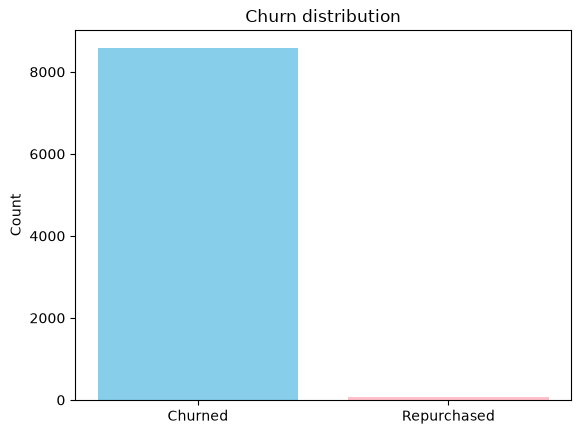

In [1219]:

plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [1220]:
y_train

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: churn_90, Length: 8662, dtype: int64

In [1221]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, random_state = 42)
X_val = X_val.astype(int)
X_test = X_test.astype(int)

In [1222]:
print(X_train.shape)
print(X_valtest.shape)

(8662, 38)
(8662, 38)


In [1223]:
my_experiment_list = [
    {
        "name":"DT - gini",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "gini",
            "max_depth": 5000,
            "random_state": 42
        }
    },
    {
        "name":"DT - entropy",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "entropy",
            "max_depth": 5000,
            "random_state": 42
        }
    },
    {
        "name":"RF - gini_50",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 50,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_100",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 100,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_300",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "entropy",
            "n_estimators": 300,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"LogReg",
        "clf":lambda **params: make_pipeline(RobustScaler(), LogisticRegression(**params)),
        "params": {
            "random_state": 42,
            "penalty": "l2",
            "C": 1.0
        }
    },
    {
        "name":"XGBoost - ",
        "clf":XGBClassifier,
        "params": {
            'objective':'binary:logistic',
            'max_depth': 20,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
    },
]

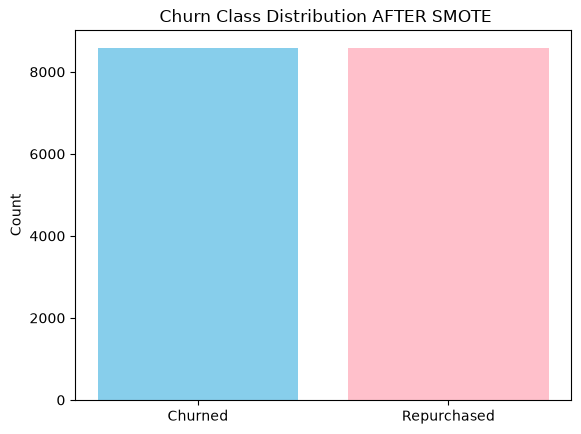

In [1224]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

-----

In [1225]:
def plot_auc(y_test, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

    # 3. Calculate AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # 4. Plot the ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')

    # Formatting details
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return auc_score

In [1226]:
a = clf.predict_proba(ds_x)

a[:, 1]>= 0.8

array([False, False, False, ...,  True, False, False], shape=(8180,))

------------------------------------
DT - gini
------------------------------------


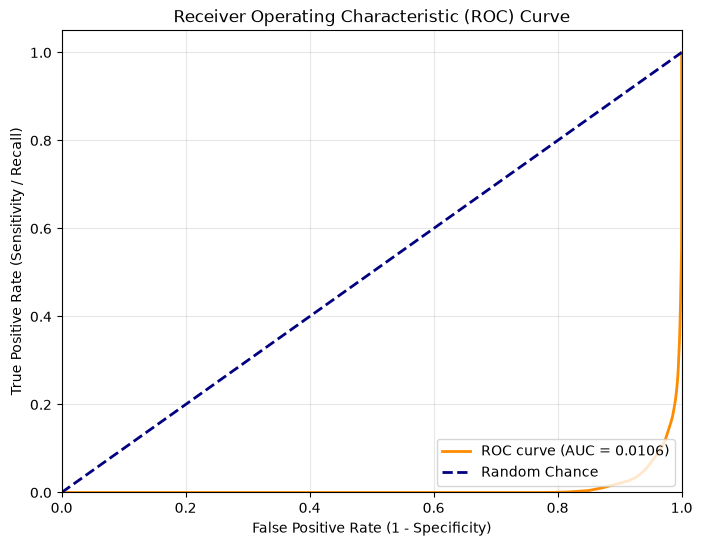

-----  Trainsm  -----
Model F1 score: 0.9449
Model accuracy: 0.9447
[[8078  505]
 [ 445 8138]]



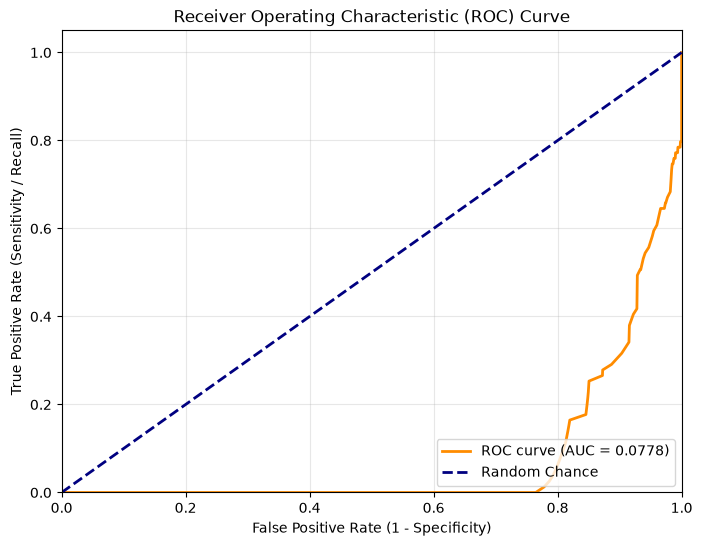

-----  Train  -----
Model F1 score: 0.1161
Model accuracy: 0.9367
[[8078  505]
 [  43   36]]



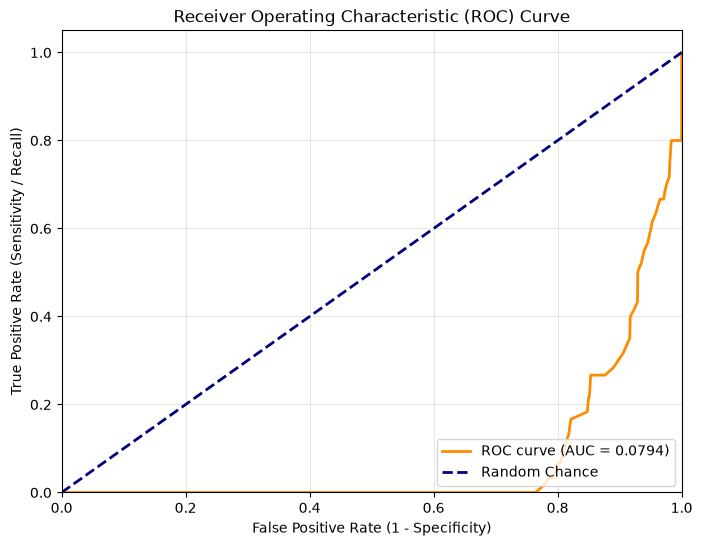

-----  Val  -----
Model F1 score: 0.1134
Model accuracy: 0.9350
[[6047  389]
 [  33   27]]



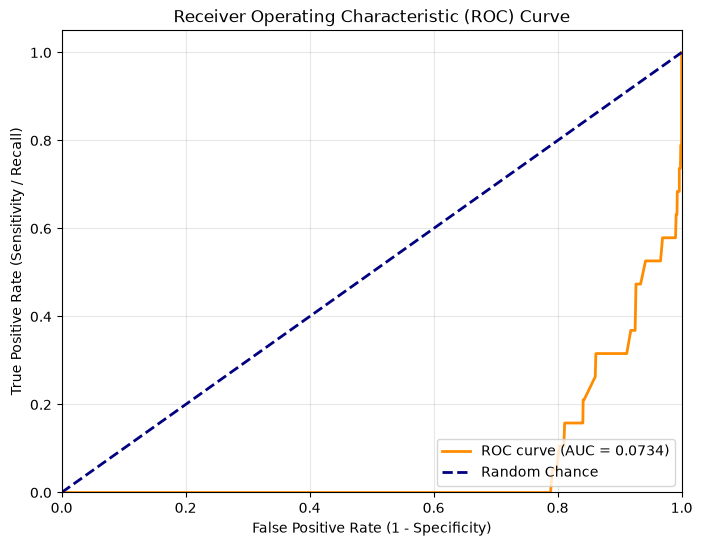

-----  Test  -----
Model F1 score: 0.1250
Model accuracy: 0.9418
[[2031  116]
 [  10    9]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


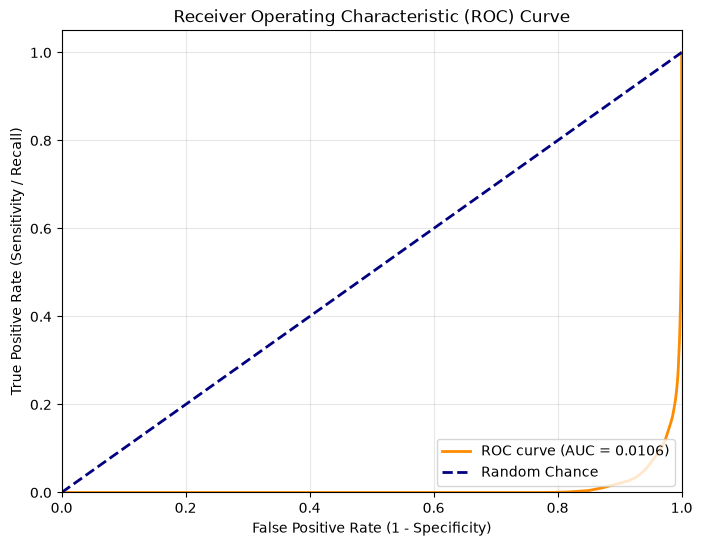

-----  Trainsm  -----
Model F1 score: 0.9449
Model accuracy: 0.9447
[[8078  505]
 [ 445 8138]]



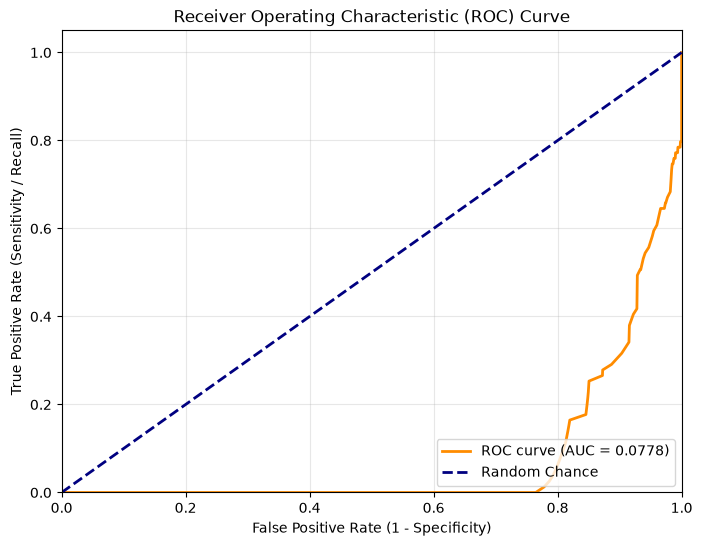

-----  Train  -----
Model F1 score: 0.1161
Model accuracy: 0.9367
[[8078  505]
 [  43   36]]



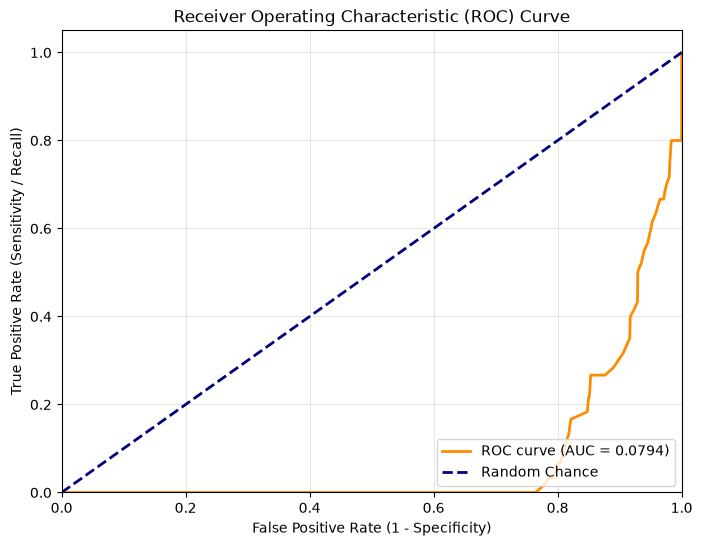

-----  Val  -----
Model F1 score: 0.1134
Model accuracy: 0.9350
[[6047  389]
 [  33   27]]



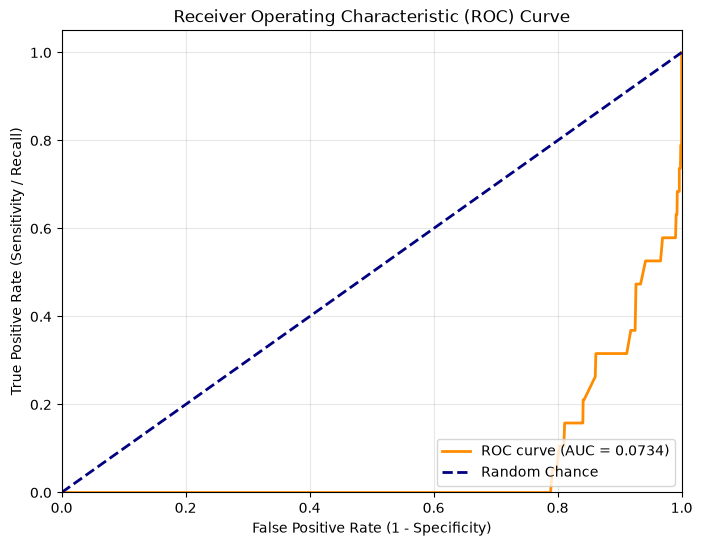

-----  Test  -----
Model F1 score: 0.1250
Model accuracy: 0.9418
[[2031  116]
 [  10    9]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


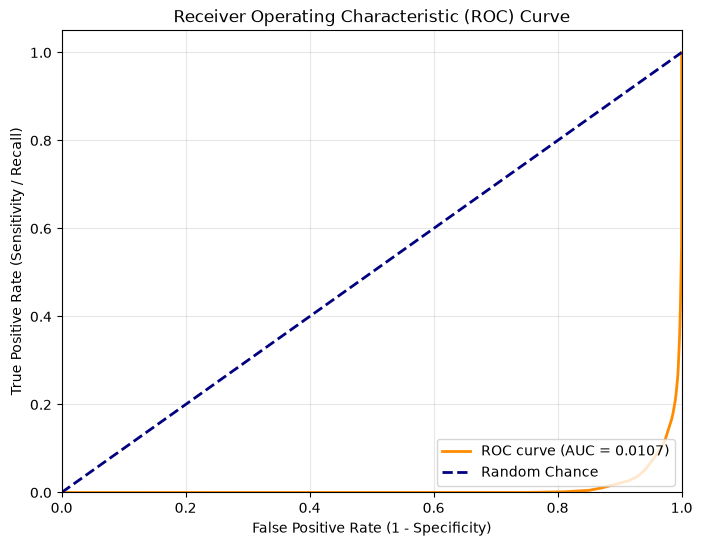

-----  Trainsm  -----
Model F1 score: 0.9447
Model accuracy: 0.9445
[[8078  505]
 [ 447 8136]]



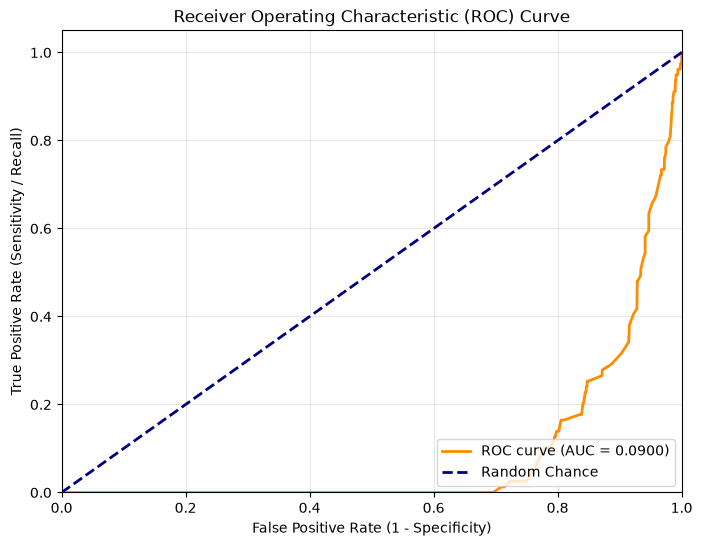

-----  Train  -----
Model F1 score: 0.1100
Model accuracy: 0.9365
[[8078  505]
 [  45   34]]



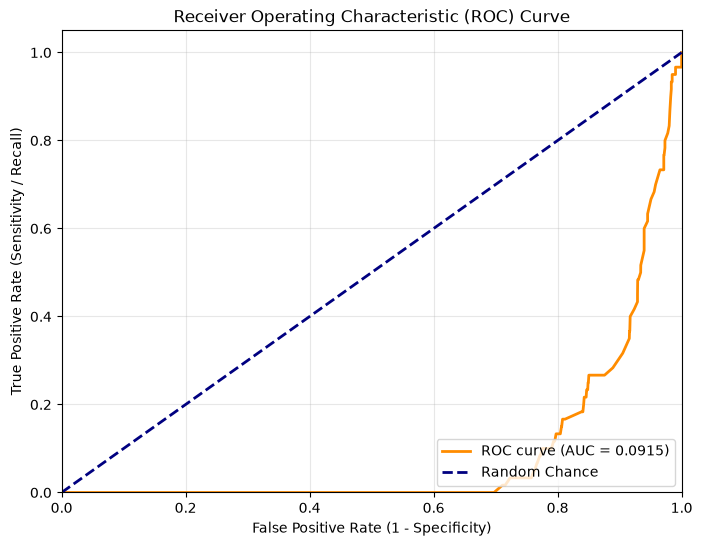

-----  Val  -----
Model F1 score: 0.1055
Model accuracy: 0.9347
[[6047  389]
 [  35   25]]



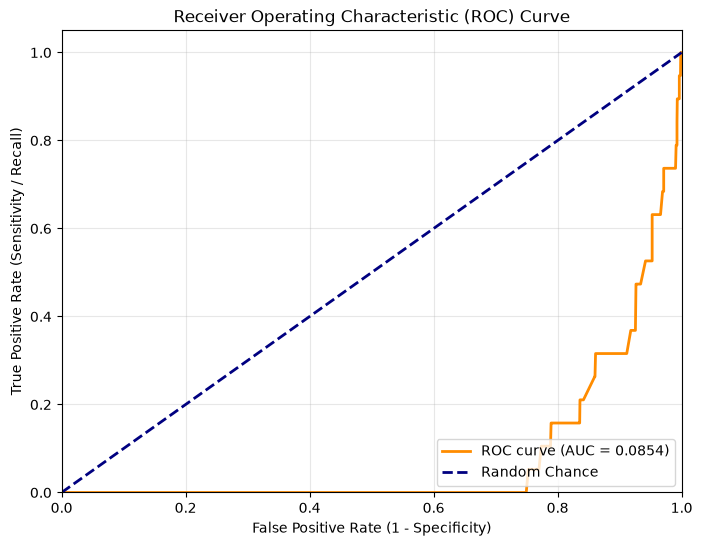

-----  Test  -----
Model F1 score: 0.1250
Model accuracy: 0.9418
[[2031  116]
 [  10    9]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


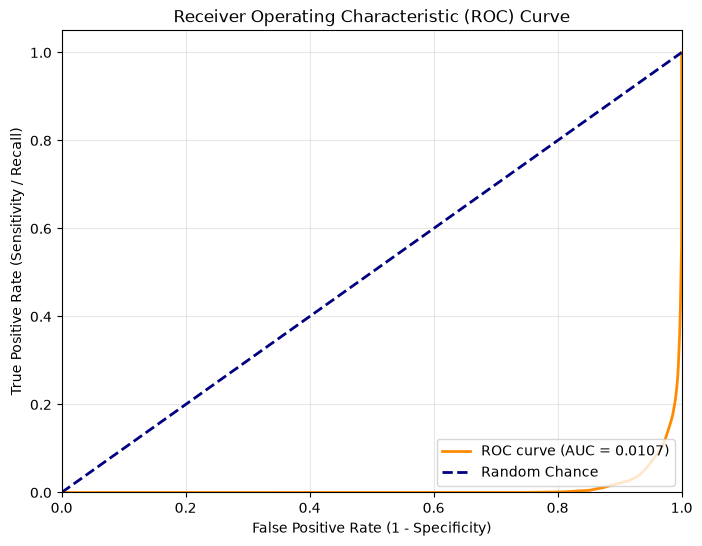

-----  Trainsm  -----
Model F1 score: 0.9448
Model accuracy: 0.9446
[[8078  505]
 [ 446 8137]]



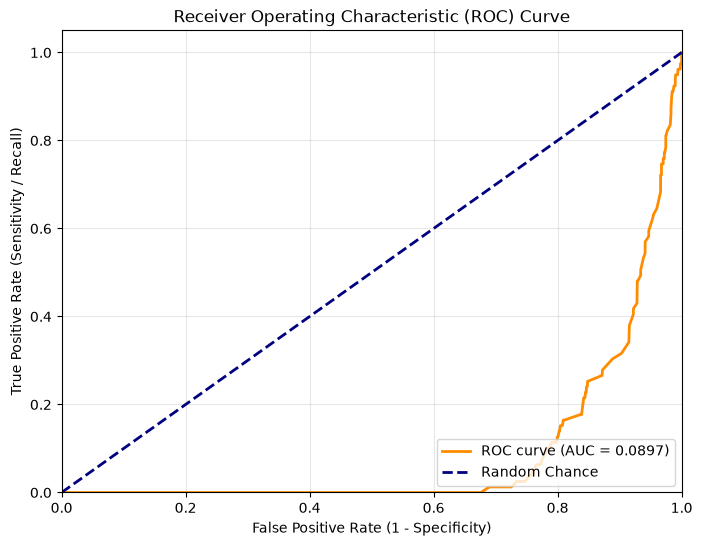

-----  Train  -----
Model F1 score: 0.1131
Model accuracy: 0.9366
[[8078  505]
 [  44   35]]



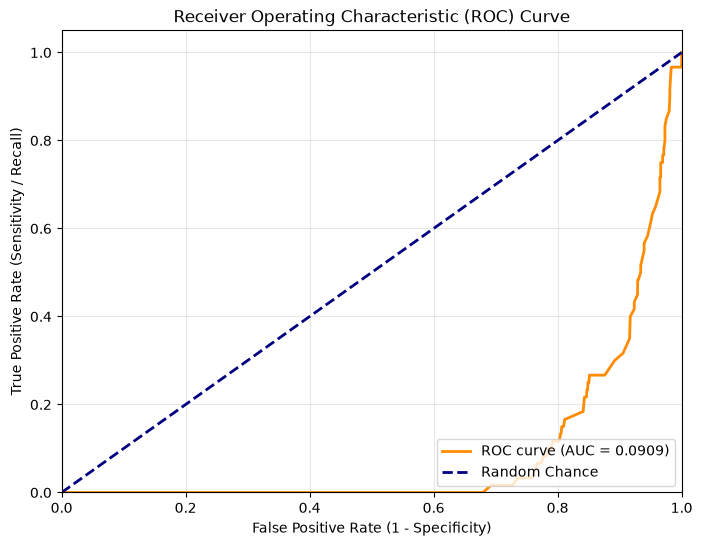

-----  Val  -----
Model F1 score: 0.1095
Model accuracy: 0.9349
[[6047  389]
 [  34   26]]



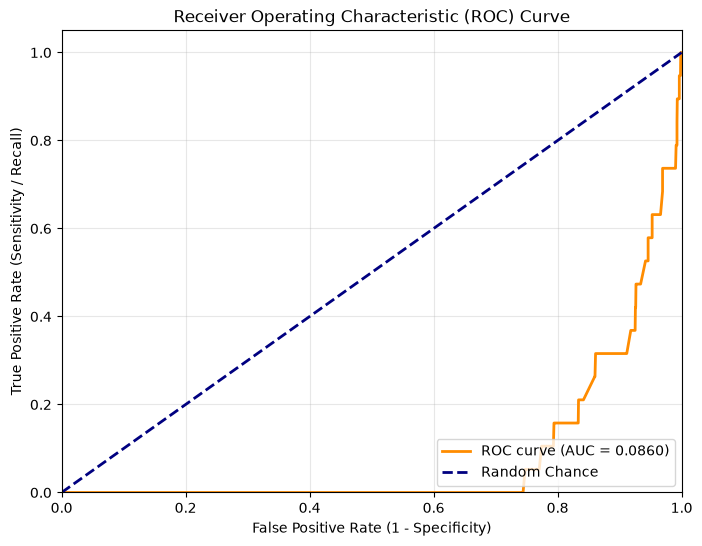

-----  Test  -----
Model F1 score: 0.1250
Model accuracy: 0.9418
[[2031  116]
 [  10    9]]

------------------------------------


------------------------------------
RF - gini_300
------------------------------------


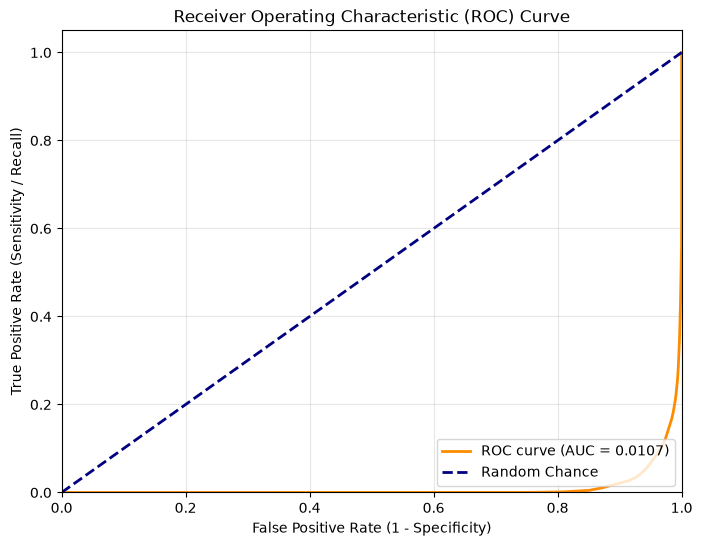

-----  Trainsm  -----
Model F1 score: 0.9449
Model accuracy: 0.9447
[[8078  505]
 [ 445 8138]]



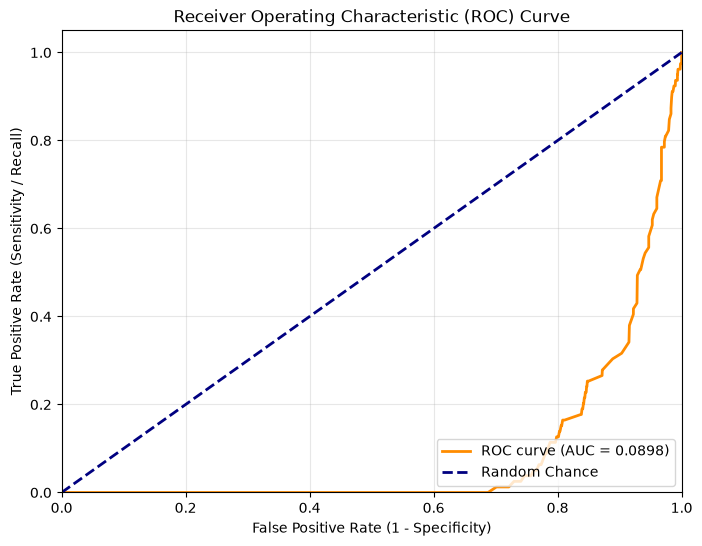

-----  Train  -----
Model F1 score: 0.1161
Model accuracy: 0.9367
[[8078  505]
 [  43   36]]



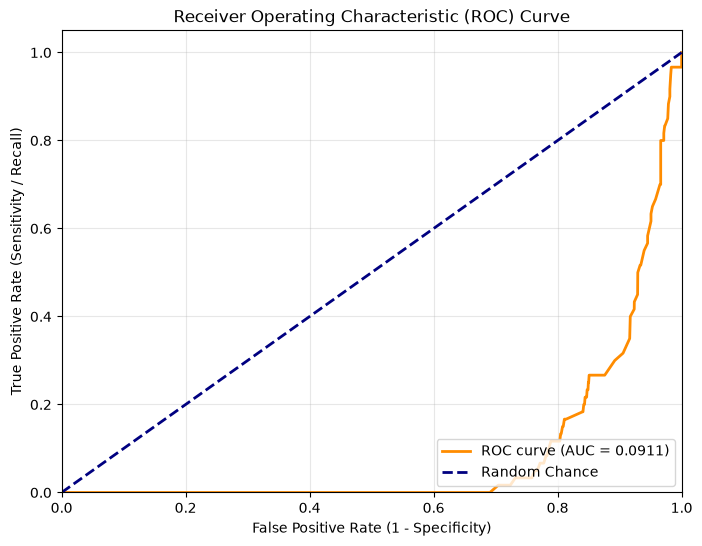

-----  Val  -----
Model F1 score: 0.1134
Model accuracy: 0.9350
[[6047  389]
 [  33   27]]



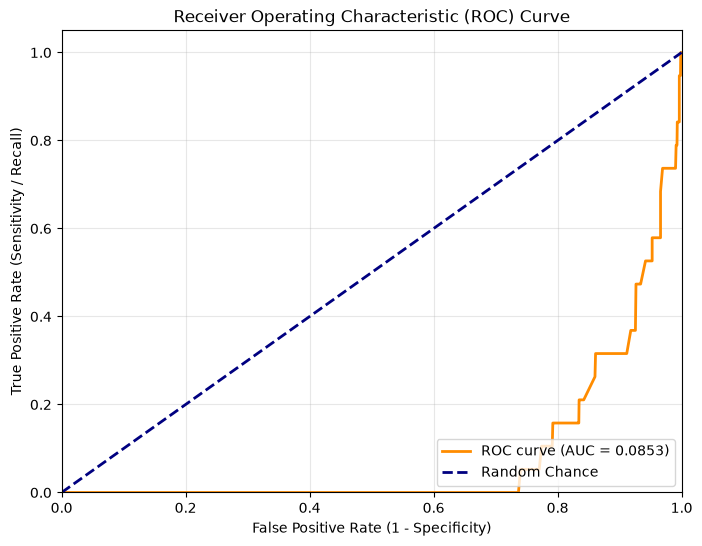

-----  Test  -----
Model F1 score: 0.1250
Model accuracy: 0.9418
[[2031  116]
 [  10    9]]

------------------------------------


------------------------------------
LogReg
------------------------------------


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


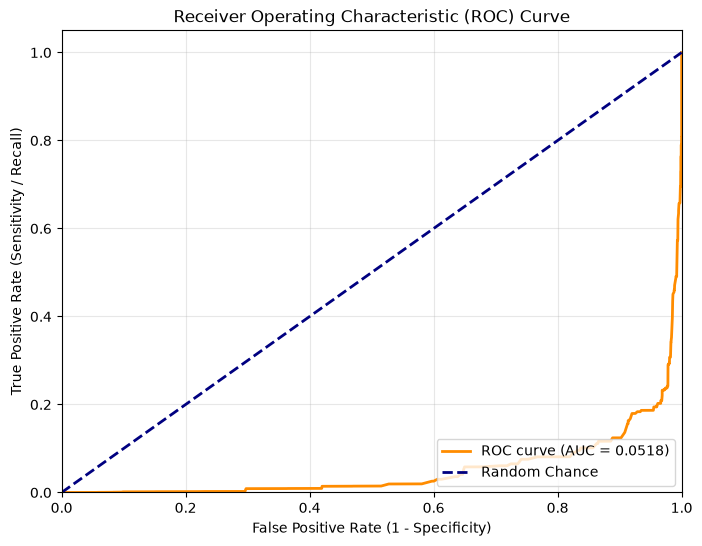

-----  Trainsm  -----
Model F1 score: 0.8698
Model accuracy: 0.8806
[[8272  311]
 [1738 6845]]



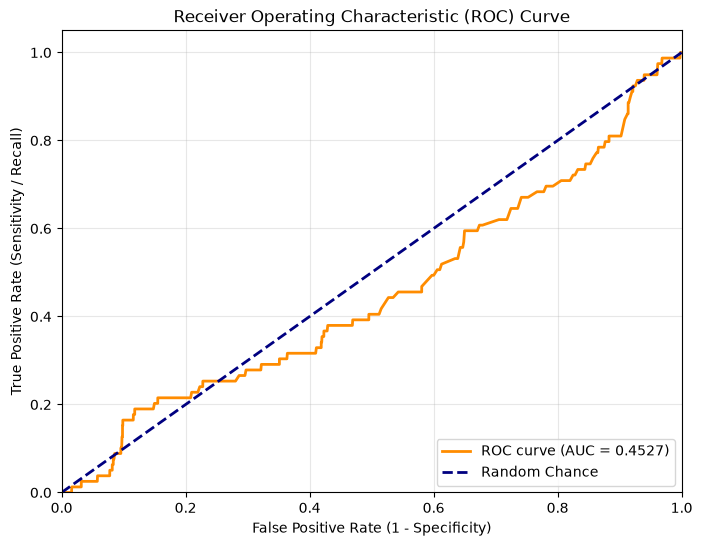

-----  Train  -----
Model F1 score: 0.0102
Model accuracy: 0.9552
[[8272  311]
 [  77    2]]



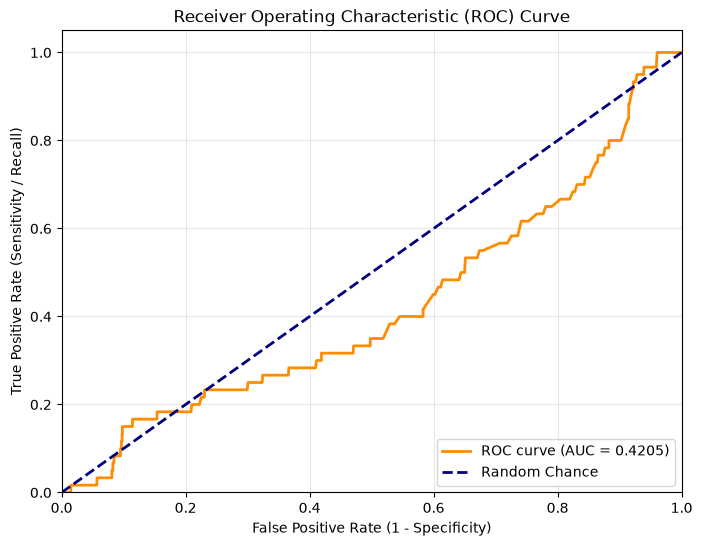

-----  Val  -----
Model F1 score: 0.0000
Model accuracy: 0.9535
[[6194  242]
 [  60    0]]



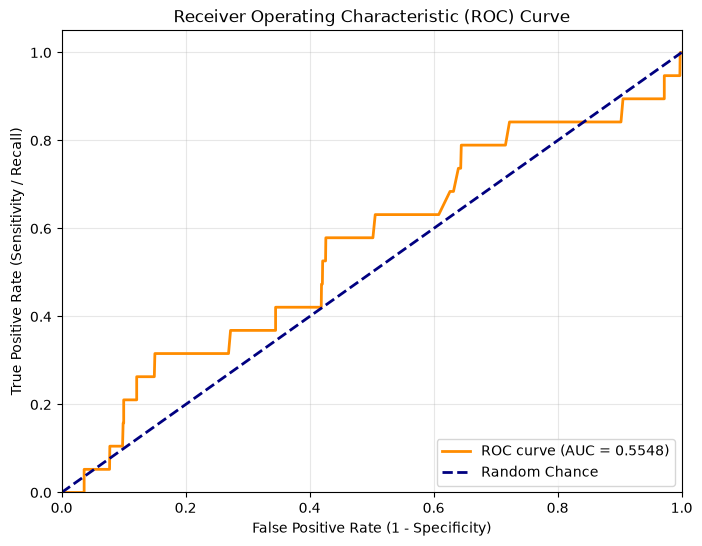

-----  Test  -----
Model F1 score: 0.0444
Model accuracy: 0.9603
[[2078   69]
 [  17    2]]

------------------------------------


------------------------------------
XGBoost - 
------------------------------------


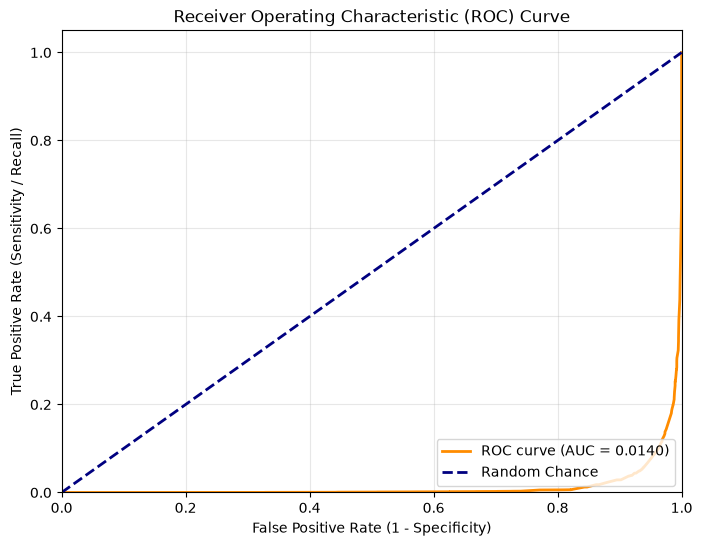

-----  Trainsm  -----
Model F1 score: 0.9355
Model accuracy: 0.9364
[[8159  424]
 [ 667 7916]]



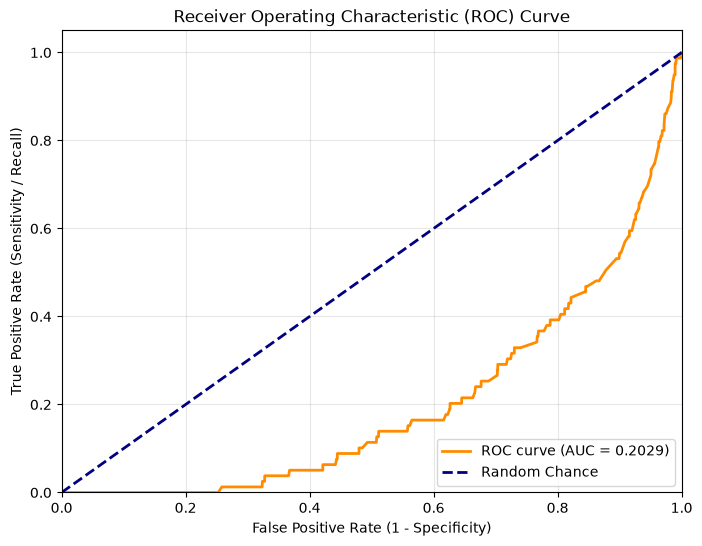

-----  Train  -----
Model F1 score: 0.0838
Model accuracy: 0.9445
[[8159  424]
 [  57   22]]



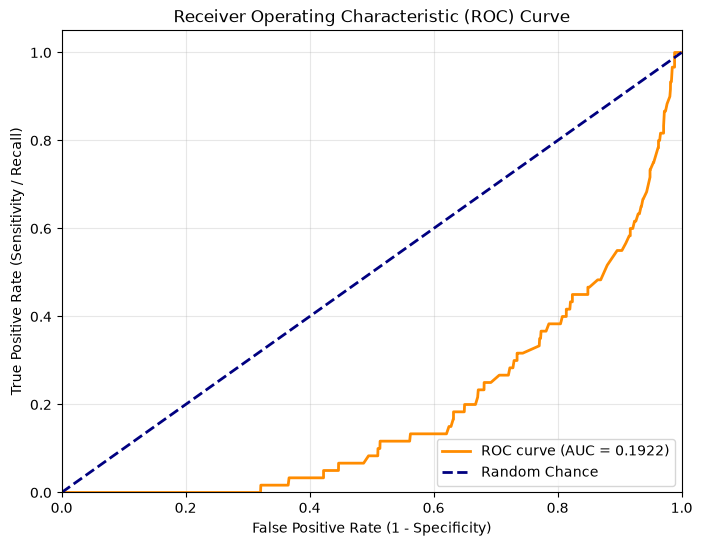

-----  Val  -----
Model F1 score: 0.0840
Model accuracy: 0.9429
[[6108  328]
 [  43   17]]



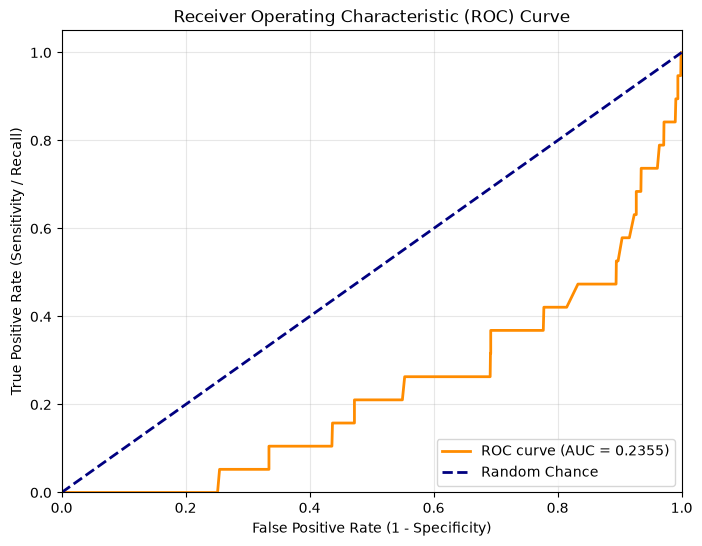

-----  Test  -----
Model F1 score: 0.0833
Model accuracy: 0.9492
[[2051   96]
 [  14    5]]

------------------------------------




In [1227]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 0]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 0, 1)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [1228]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

,name,Trainsm_f1sore,Trainsm_acc,Trainsm_auc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,Train_acc,...,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_auc,Test_tn,Test_fp,Test_fn,Test_tp
0,DT - gini,0.944851,0.944658,0.010570,8078,505,445,8138,0.116129,0.936735,...,389,33,27,0.125000,0.941828,0.073419,2031,116,10,9
1,DT - entropy,0.944851,0.944658,0.010570,8078,505,445,8138,0.116129,0.936735,...,389,33,27,0.125000,0.941828,0.073419,2031,116,10,9
2,RF - gini_50,0.944728,0.944542,0.010728,8078,505,447,8136,0.110032,0.936504,...,389,35,25,0.125000,0.941828,0.085370,2031,116,10,9
3,RF - gini_100,0.944790,0.944600,0.010711,8078,505,446,8137,0.113086,0.936620,...,389,34,26,0.125000,0.941828,0.085958,2031,116,10,9
4,RF - gini_300,0.944851,0.944658,0.010708,8078,505,445,8138,0.116129,0.936735,...,389,33,27,0.125000,0.941828,0.085272,2031,116,10,9
6,XGBoost -,0.935532,0.936444,0.013951,8159,424,667,7916,0.083810,0.944470,...,328,43,17,0.083333,0.949215,0.235494,2051,96,14,5
5,LogReg,0.869814,0.880636,0.051841,8272,311,1738,6845,0.010204,0.955207,...,242,60,0,0.044444,0.960295,0.554764,2078,69,17,2


In [1229]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train_sm, X_train_sm).fit()

print(model_stm.summary())

         Current function value: 0.443284
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               churn_90   No. Observations:                17166
Model:                          Logit   Df Residuals:                    17128
Method:                           MLE   Df Model:                           37
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.3605
Time:                        00:03:38   Log-Likelihood:                -7609.4
converged:                      False   LL-Null:                       -11899.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                -0.6010      1.062     -0.566      0.571      

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


--------
--------

## 120 days train_test dataset

In [1230]:
Data_train_120_df["state_income_level"] = Data_train_120_df.customer_state.map(prov_income_map)

Data_train_120_df["state_income_level_high"] = (Data_train_120_df["state_income_level"] == "high").astype(int)
Data_train_120_df["state_income_level_mid"] = (Data_train_120_df["state_income_level"] == "mid").astype(int)
Data_train_120_df["state_income_level_low"] = (Data_train_120_df["state_income_level"] == "low").astype(int)

Data_train_120_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,delivered,1.0,credit_card,10.0,household,0,low,0,0,1
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,processing,1.0,boleto,1.0,household,0,high,1,0,0
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,delivered,1.0,credit_card,10.0,entertainment,0,high,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,canceled,1.0,credit_card,4.0,automotive,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,ffe2dd1f3b0cbf0b5f35e818ec03c49b,89.99,0.230137,110.70,-9.0,4.0,0.011834,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,2.0,household,0,high,1,0,0
7796,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,delivered,1.0,boleto,1.0,construction,0,low,0,0,1
7797,ffebb6424578e7bb153322da9d65634f,629.00,0.058347,665.70,-5.0,1.0,0.005169,2.0,guarulhos,SP,delivered,1.0,credit_card,8.0,entertainment,0,high,1,0,0
7798,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0


In [1231]:

Data_train_120_df["high_review_score"] = (Data_train_120_df["review_score"]>= 4).astype(int)
Data_train_120_df["medium_review_score"] = ((Data_train_120_df["review_score"]< 4) & (Data_train_120_df["review_score"]>= 2)).astype(int)
Data_train_120_df["low_review_score"] = (Data_train_120_df["review_score"]< 2).astype(int)

Data_train_120_df


,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,...,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,...,1.0,entertainment,0,high,1,0,0,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,...,10.0,household,0,low,0,0,1,1,0,0
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,...,1.0,household,0,high,1,0,0,0,0,1
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,...,10.0,entertainment,0,high,1,0,0,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,...,4.0,automotive,0,low,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,ffe2dd1f3b0cbf0b5f35e818ec03c49b,89.99,0.230137,110.70,-9.0,4.0,0.011834,1.0,rio de janeiro,RJ,...,2.0,household,0,high,1,0,0,1,0,0
7796,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,...,1.0,construction,0,low,0,0,1,0,0,1
7797,ffebb6424578e7bb153322da9d65634f,629.00,0.058347,665.70,-5.0,1.0,0.005169,2.0,guarulhos,SP,...,8.0,entertainment,0,high,1,0,0,0,0,1
7798,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,...,3.0,household,0,high,1,0,0,1,0,0


In [1232]:
Data_train_120_df["delay"] = (Data_train_120_df["dates_diff"]>0).astype(int)

Data_train_120_df["delay"]

0       0
1       0
2       0
3       0
4       0
       ..
7795    0
7796    0
7797    0
7798    0
7799    0
Name: delay, Length: 7800, dtype: int64

In [1233]:
Data_train_120_df["high_payment_value"] = (Data_train_120_df["payment_value"]>172.73).astype(int)

Data_train_120_df["high_payment_value"]

0       0
1       1
2       0
3       1
4       1
       ..
7795    0
7796    0
7797    1
7798    0
7799    0
Name: high_payment_value, Length: 7800, dtype: int64

In [1234]:
Data_train_120_df["expensive_freight"] = (Data_train_120_df["freight_to_price_ratio"]>0.15).astype(int)

Data_train_120_df["expensive_freight"]

0       0
1       0
2       1
3       0
4       1
       ..
7795    1
7796    0
7797    0
7798    1
7799    1
Name: expensive_freight, Length: 7800, dtype: int64

In [1235]:
Data_train_120_df["high_freight_to_weight"] = (Data_train_120_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_train_120_df["high_freight_to_weight"]

0       0
1       0
2       0
3       0
4       0
       ..
7795    0
7796    0
7797    0
7798    0
7799    0
Name: high_freight_to_weight, Length: 7800, dtype: int64

In [1236]:
Data_train_120_df["is_high_price"] = (Data_train_120_df["price"]>120.64).astype(int)

Data_train_120_df["is_high_price"]

0       1
1       1
2       0
3       1
4       1
       ..
7795    0
7796    1
7797    1
7798    0
7799    0
Name: is_high_price, Length: 7800, dtype: int64

In [1237]:
Data_train_120_df["beyond_one year"] = (Data_train_120_df["payment_installments"] > 12.0).astype(int)

Data_train_120_df["beyond_one year"]

0       0
1       0
2       0
3       0
4       0
       ..
7795    0
7796    0
7797    0
7798    0
7799    0
Name: beyond_one year, Length: 7800, dtype: int64

In [1238]:
Data_train_120_df["multiple_payment_methods"] = (Data_train_120_df["payment_sequential"] > 2.0).astype(int)

Data_train_120_df["multiple_payment_methods"]

0       0
1       0
2       0
3       0
4       0
       ..
7795    0
7796    0
7797    0
7798    0
7799    0
Name: multiple_payment_methods, Length: 7800, dtype: int64

In [1239]:
Data_train_120_df["low_foto_count"] = (Data_train_120_df["product_photos_qty"] < 2).astype(int)

Data_train_120_df["low_foto_count"]

0       1
1       0
2       1
3       0
4       1
       ..
7795    1
7796    0
7797    0
7798    1
7799    0
Name: low_foto_count, Length: 7800, dtype: int64

In [1240]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_120_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [1241]:
encoded_array = col_trans.transform(Data_train_120_df)

In [1242]:
encoded_120_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_120_df.columns))

encoded_120_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__high_freight_to_weight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods,remainder__low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,1,0,0,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
7796,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
7797,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,0
7798,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1


In [1243]:
encoded_120_df.columns = encoded_120_df.columns.str.replace('remainder__', '')

encoded_120_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,high_freight_to_weight,is_high_price,beyond_one year,multiple_payment_methods,low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,1,0,0,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
7796,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
7797,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,0
7798,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1


-----

## Test dataset

In [1244]:
Data_test_120_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
1,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0
2,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0
3,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0
4,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,ffe76cb2f4bb39384c432d65ece67441,49.00,0.348163,66.06,-15.0,5.0,0.068240,3.0,camacari,BA,delivered,1.0,boleto,1.0,beauty,0
39953,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,0.104800,1.0,viana,ES,delivered,1.0,credit_card,3.0,sports_leisure,0
39954,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0
39955,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0


In [1245]:
Data_test_120_df["state_income_level"] = Data_test_120_df.customer_state.map(prov_income_map)

Data_test_120_df["state_income_level_high"] = (Data_test_120_df["state_income_level"] == "high").astype(int)
Data_test_120_df["state_income_level_mid"] = (Data_test_120_df["state_income_level"] == "mid").astype(int)
Data_test_120_df["state_income_level_low"] = (Data_test_120_df["state_income_level"] == "low").astype(int)

Data_test_120_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
1,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0,low,0,0,1
2,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
3,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0,low,0,0,1
4,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,ffe76cb2f4bb39384c432d65ece67441,49.00,0.348163,66.06,-15.0,5.0,0.068240,3.0,camacari,BA,delivered,1.0,boleto,1.0,beauty,0,mid,0,1,0
39953,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,0.104800,1.0,viana,ES,delivered,1.0,credit_card,3.0,sports_leisure,0,mid,0,1,0
39954,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0,high,1,0,0
39955,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0


In [1246]:
Data_test_120_df["high_review_score"] = (Data_test_120_df["review_score"]>= 4).astype(int)
Data_test_120_df["medium_review_score"] = ((Data_test_120_df["review_score"]< 4) & (Data_test_120_df["review_score"]>= 2)).astype(int)
Data_test_120_df["low_review_score"] = (Data_test_120_df["review_score"]< 2).astype(int)

Data_test_120_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,...,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,...,3.0,sports_leisure,0,low,0,0,1,0,0,1
1,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,...,4.0,sports_leisure,0,low,0,0,1,0,0,1
2,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,...,3.0,household,0,high,1,0,0,1,0,0
3,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,...,2.0,household,0,low,0,0,1,1,0,0
4,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,...,1.0,electronics,0,high,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,ffe76cb2f4bb39384c432d65ece67441,49.00,0.348163,66.06,-15.0,5.0,0.068240,3.0,camacari,BA,...,1.0,beauty,0,mid,0,1,0,1,0,0
39953,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,0.104800,1.0,viana,ES,...,3.0,sports_leisure,0,mid,0,1,0,1,0,0
39954,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,...,1.0,fashion,0,high,1,0,0,1,0,0
39955,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,...,8.0,office,0,high,1,0,0,1,0,0


In [1247]:
Data_test_120_df["delay"] = (Data_test_120_df["dates_diff"]>0).astype(int)

Data_test_120_df["delay"]

0        0
1        1
2        0
3        0
4        0
        ..
39952    0
39953    0
39954    0
39955    0
39956    0
Name: delay, Length: 39957, dtype: int64

In [1248]:
Data_test_120_df["high_payment_value"] = (Data_test_120_df["payment_value"]>172.73).astype(int)

Data_test_120_df["high_payment_value"]

0        1
1        0
2        0
3        0
4        0
        ..
39952    0
39953    0
39954    0
39955    1
39956    1
Name: high_payment_value, Length: 39957, dtype: int64

In [1249]:
Data_test_120_df["expensive_freight"] = (Data_test_120_df["freight_to_price_ratio"]>0.15).astype(int)

Data_test_120_df["expensive_freight"]

0        0
1        1
2        1
3        1
4        1
        ..
39952    1
39953    0
39954    1
39955    1
39956    0
Name: expensive_freight, Length: 39957, dtype: int64

In [1250]:
Data_test_120_df["high_freight_to_weight"] = (Data_test_120_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_test_120_df["high_freight_to_weight"]

0        0
1        0
2        0
3        0
4        0
        ..
39952    0
39953    0
39954    0
39955    0
39956    0
Name: high_freight_to_weight, Length: 39957, dtype: int64

In [1251]:
Data_test_120_df["is_high_price"] = (Data_test_120_df["price"]>120.64).astype(int)

Data_test_120_df["is_high_price"] 

0        1
1        0
2        0
3        0
4        0
        ..
39952    0
39953    0
39954    0
39955    1
39956    1
Name: is_high_price, Length: 39957, dtype: int64

In [1252]:
Data_test_120_df["beyond_one year"] = (Data_test_120_df["payment_installments"] > 12.0).astype(int)

Data_test_120_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
39952    0
39953    0
39954    0
39955    0
39956    0
Name: beyond_one year, Length: 39957, dtype: int64

In [1253]:
Data_test_120_df["multiple_payment_methods"] = (Data_test_120_df["payment_sequential"] > 2.0).astype(int)

Data_test_120_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
39952    0
39953    0
39954    0
39955    0
39956    0
Name: multiple_payment_methods, Length: 39957, dtype: int64

In [1254]:
Data_test_120_df["low_foto_count"] = (Data_test_120_df["product_photos_qty"] < 2).astype(int)

Data_test_120_df["low_foto_count"]

0        1
1        1
2        0
3        0
4        0
        ..
39952    0
39953    1
39954    1
39955    1
39956    0
Name: low_foto_count, Length: 39957, dtype: int64

In [1255]:
encoded_array_test = col_trans.transform(Data_test_120_df)

In [1256]:
encoded_120_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_120_df.columns))

encoded_120_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__high_freight_to_weight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods,remainder__low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,1,0,1,0,0,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
39953,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
39954,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
39955,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,1,0,1,0,0,1


In [1257]:
encoded_120_test_df.columns = encoded_120_test_df.columns.str.replace('remainder__', '')

encoded_120_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,high_freight_to_weight,is_high_price,beyond_one year,multiple_payment_methods,low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,1
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,1,0,1,0,0,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39952,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
39953,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
39954,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
39955,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,1,0,1,0,0,1


-----

## Train test split

In [1258]:
X_train = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id",  "customer_city", "customer_state", "payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_train = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [1259]:
X_valtest = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id", "customer_city", "customer_state", "payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [1260]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, random_state = 42)

In [1261]:
print(X_train.shape)
print(X_valtest.shape)

(39957, 38)
(39957, 38)


In [1262]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

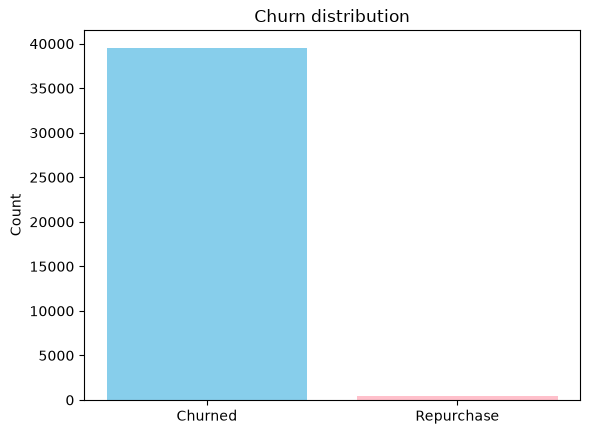

In [1263]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchase"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [1264]:
X_valtest.columns

Index(['cat__order_status_canceled', 'cat__order_status_delivered',
       'cat__order_status_invoiced', 'cat__order_status_processing',
       'cat__order_status_shipped', 'cat__order_status_unavailable',
       'cat__payment_type_credit_card', 'cat__payment_type_debit_card',
       'cat__payment_type_voucher', 'cat__product_cat_babies',
       'cat__product_cat_beauty', 'cat__product_cat_books_media',
       'cat__product_cat_commercial_industrial',
       'cat__product_cat_construction', 'cat__product_cat_electronics',
       'cat__product_cat_entertainment', 'cat__product_cat_fashion',
       'cat__product_cat_food_drink', 'cat__product_cat_household',
       'cat__product_cat_miscellaneous', 'cat__product_cat_office',
       'cat__product_cat_pet_shop', 'cat__product_cat_sports_leisure',
       'cat__product_cat_unknown', 'state_income_level_high',
       'state_income_level_mid', 'state_income_level_low', 'high_review_score',
       'medium_review_score', 'low_review_score', 'del

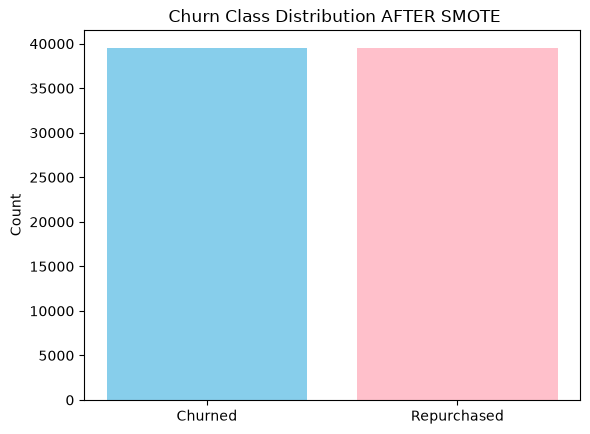

In [1265]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

------------------------------------
DT - gini
------------------------------------


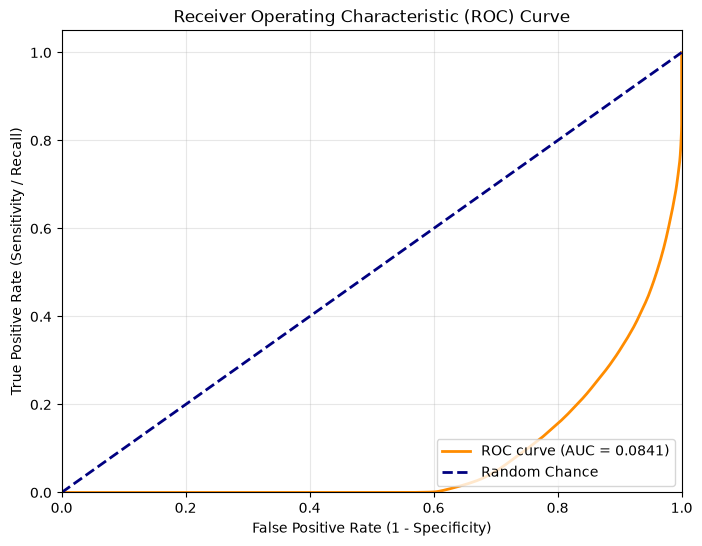

-----  Trainsm  -----
Model F1 score: 0.8092
Model accuracy: 0.8138
[[33131  6394]
 [ 8323 31202]]



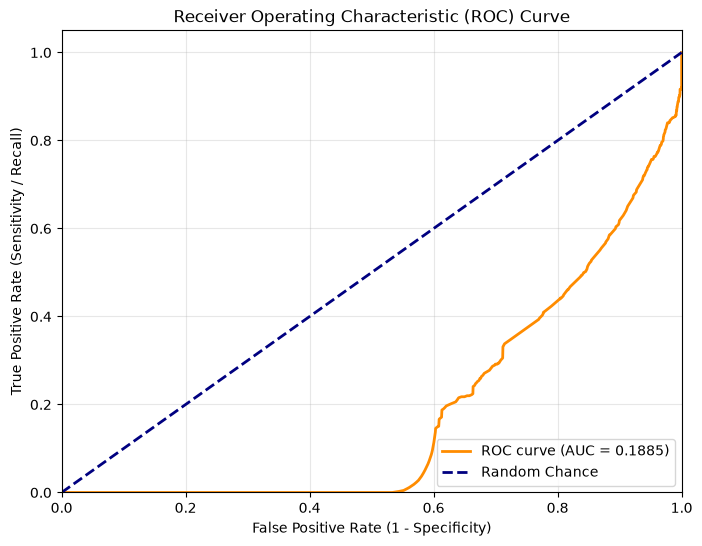

-----  Train  -----
Model F1 score: 0.0622
Model accuracy: 0.8346
[[33131  6394]
 [  213   219]]



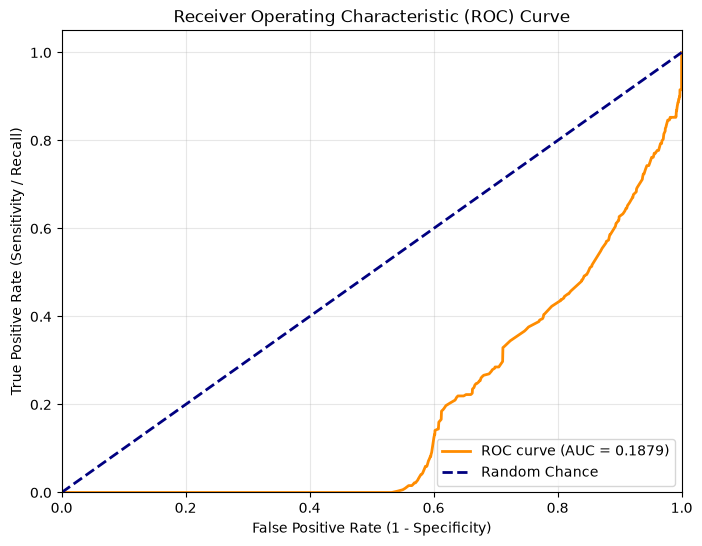

-----  Val  -----
Model F1 score: 0.0628
Model accuracy: 0.8358
[[24881  4767]
 [  154   165]]



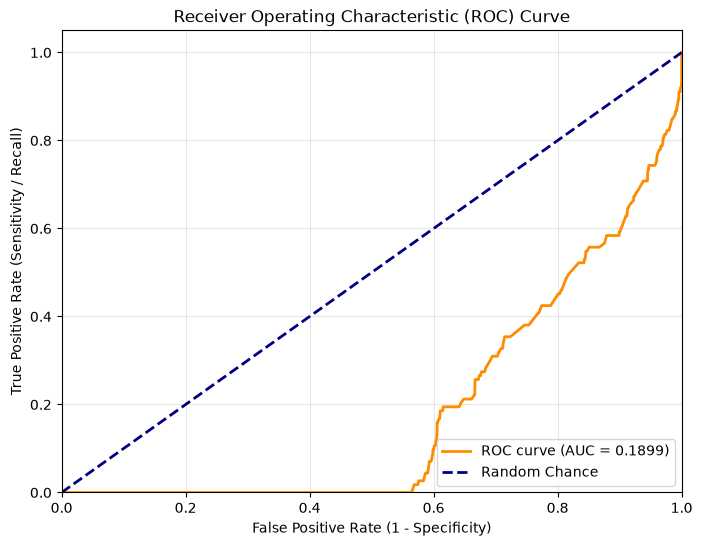

-----  Test  -----
Model F1 score: 0.0602
Model accuracy: 0.8312
[[8250 1627]
 [  59   54]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


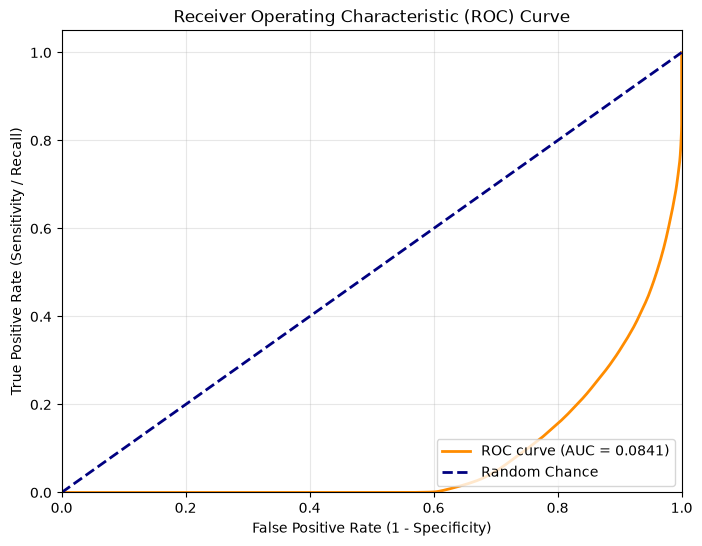

-----  Trainsm  -----
Model F1 score: 0.8092
Model accuracy: 0.8138
[[33131  6394]
 [ 8323 31202]]



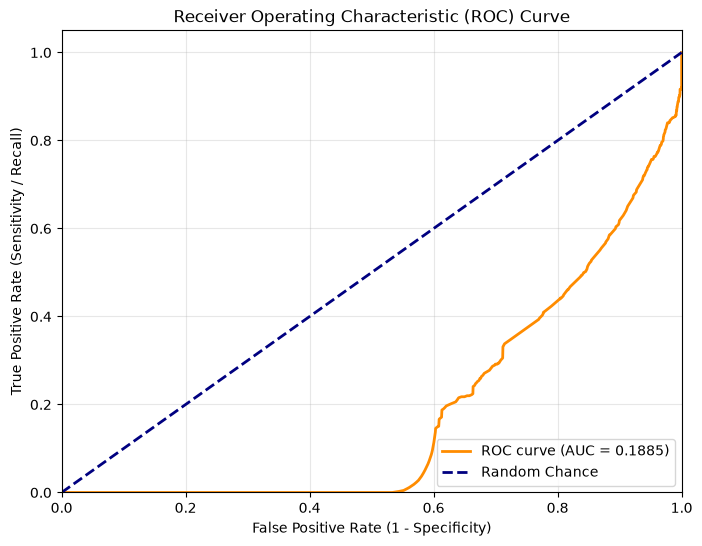

-----  Train  -----
Model F1 score: 0.0622
Model accuracy: 0.8346
[[33131  6394]
 [  213   219]]



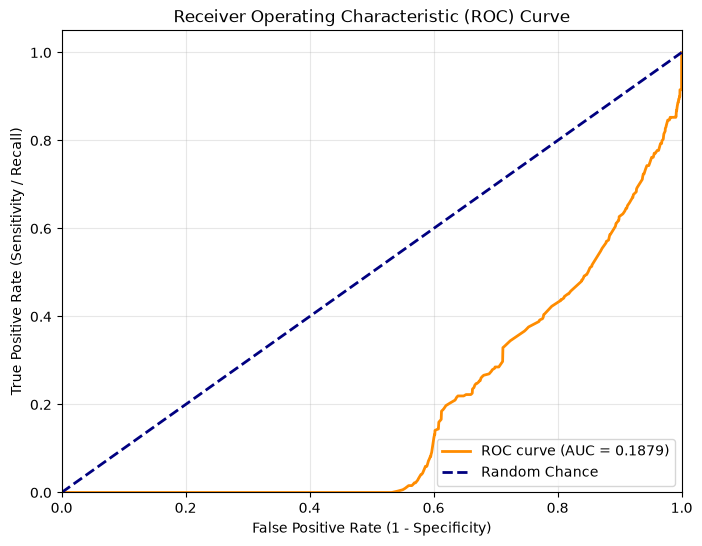

-----  Val  -----
Model F1 score: 0.0628
Model accuracy: 0.8358
[[24881  4767]
 [  154   165]]



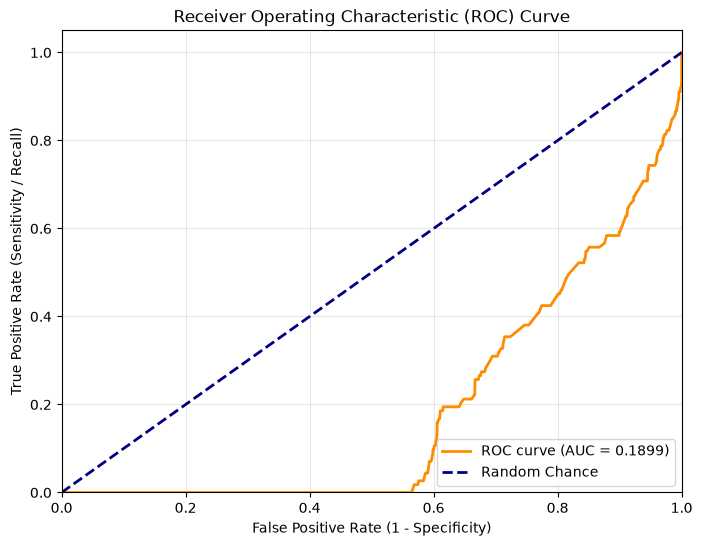

-----  Test  -----
Model F1 score: 0.0602
Model accuracy: 0.8312
[[8250 1627]
 [  59   54]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


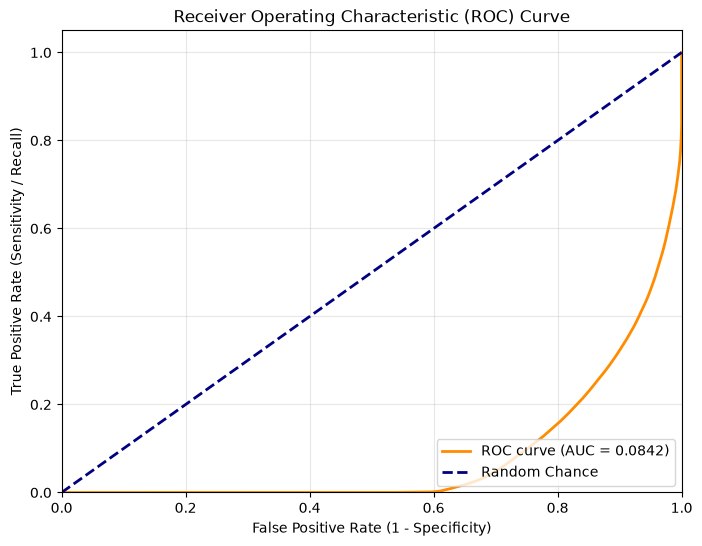

-----  Trainsm  -----
Model F1 score: 0.8097
Model accuracy: 0.8141
[[33088  6437]
 [ 8262 31263]]



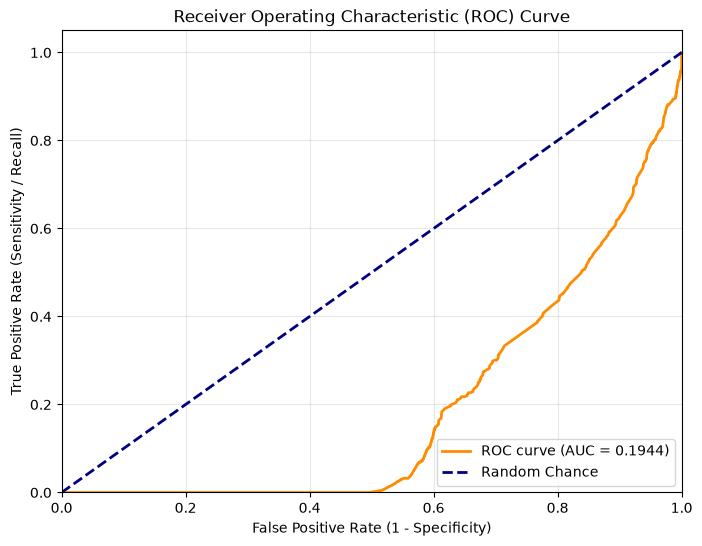

-----  Train  -----
Model F1 score: 0.0612
Model accuracy: 0.8335
[[33088  6437]
 [  215   217]]



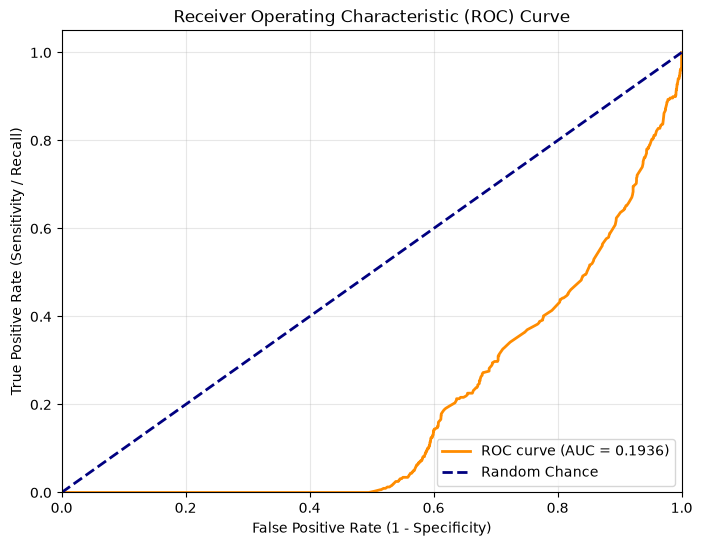

-----  Val  -----
Model F1 score: 0.0625
Model accuracy: 0.8348
[[24850  4798]
 [  154   165]]



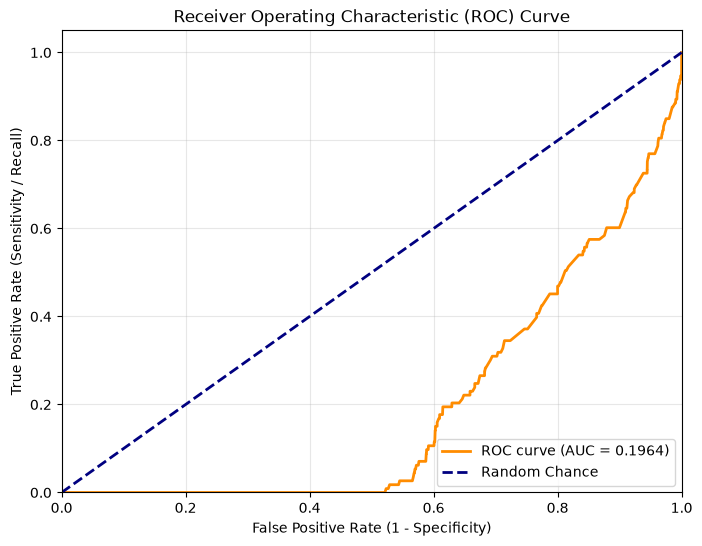

-----  Test  -----
Model F1 score: 0.0576
Model accuracy: 0.8298
[[8238 1639]
 [  61   52]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


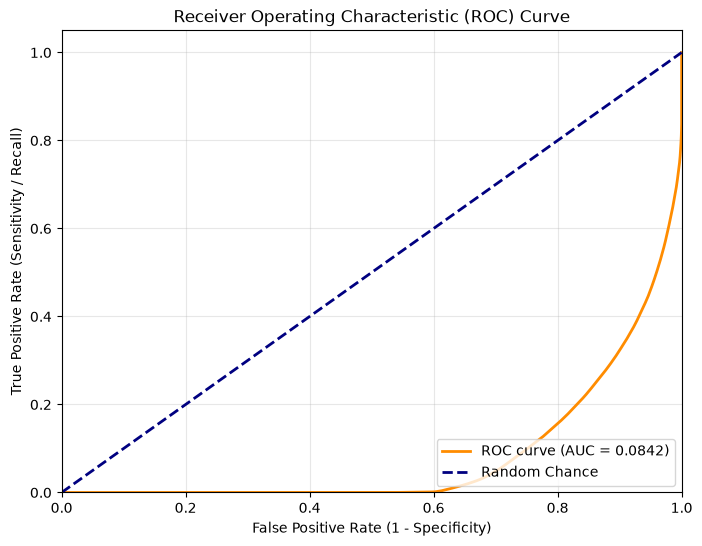

-----  Trainsm  -----
Model F1 score: 0.8097
Model accuracy: 0.8141
[[33088  6437]
 [ 8261 31264]]



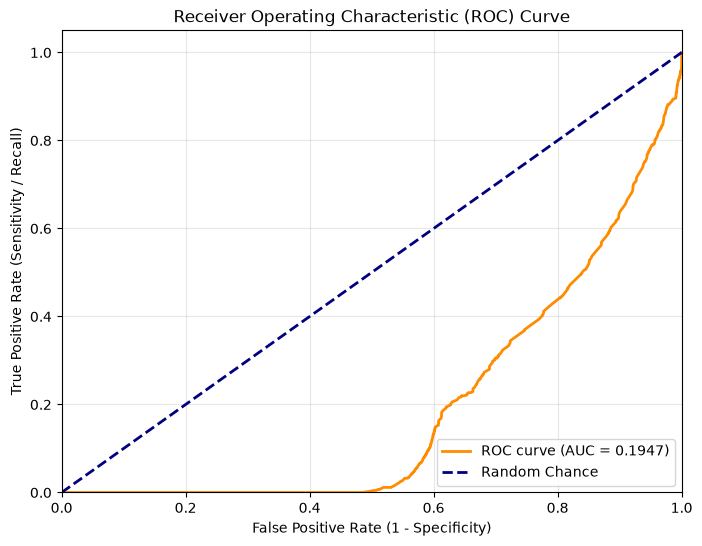

-----  Train  -----
Model F1 score: 0.0615
Model accuracy: 0.8335
[[33088  6437]
 [  214   218]]



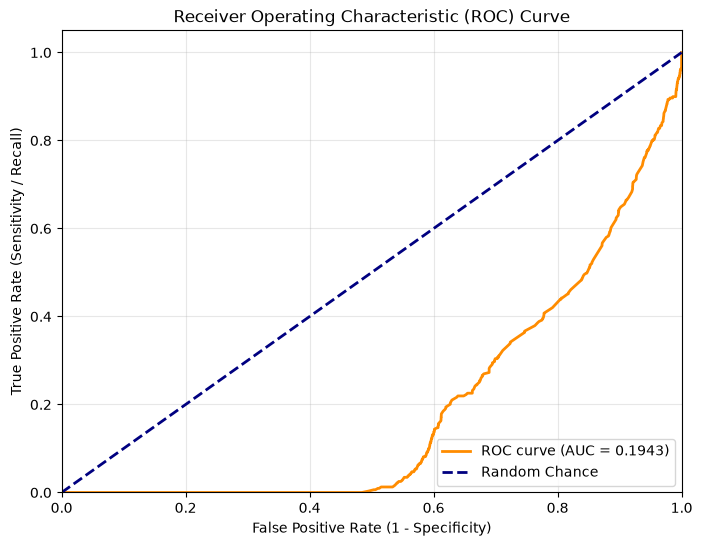

-----  Val  -----
Model F1 score: 0.0625
Model accuracy: 0.8348
[[24850  4798]
 [  154   165]]



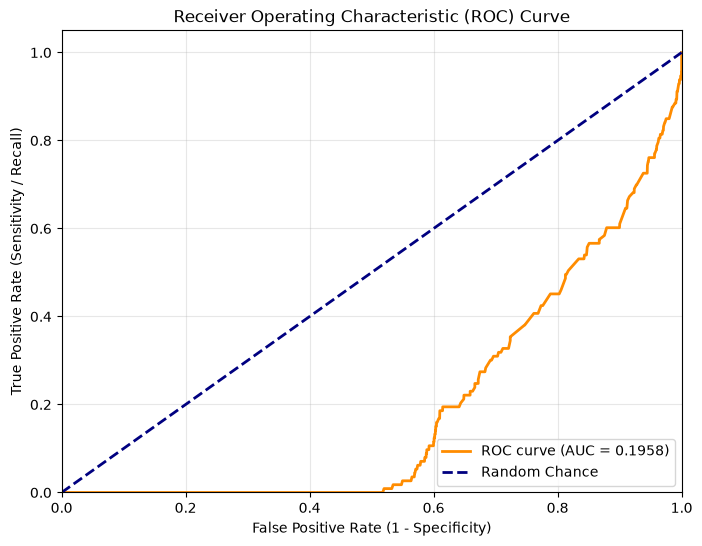

-----  Test  -----
Model F1 score: 0.0587
Model accuracy: 0.8299
[[8238 1639]
 [  60   53]]

------------------------------------


------------------------------------
RF - gini_300
------------------------------------


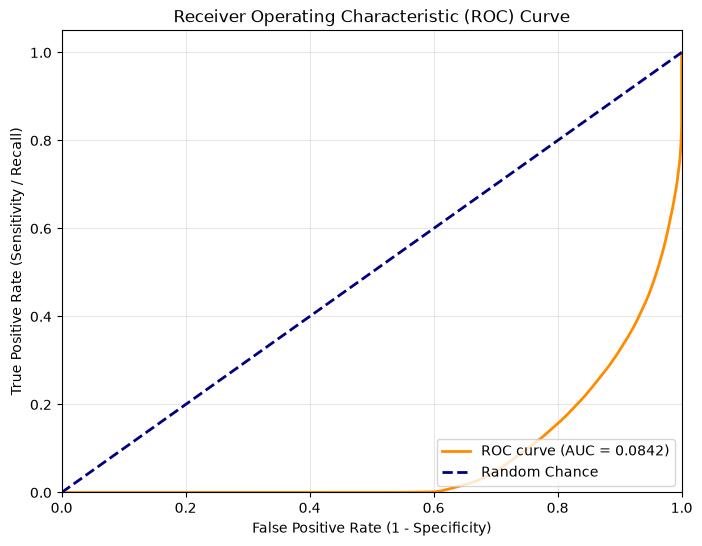

-----  Trainsm  -----
Model F1 score: 0.8091
Model accuracy: 0.8138
[[33134  6391]
 [ 8328 31197]]



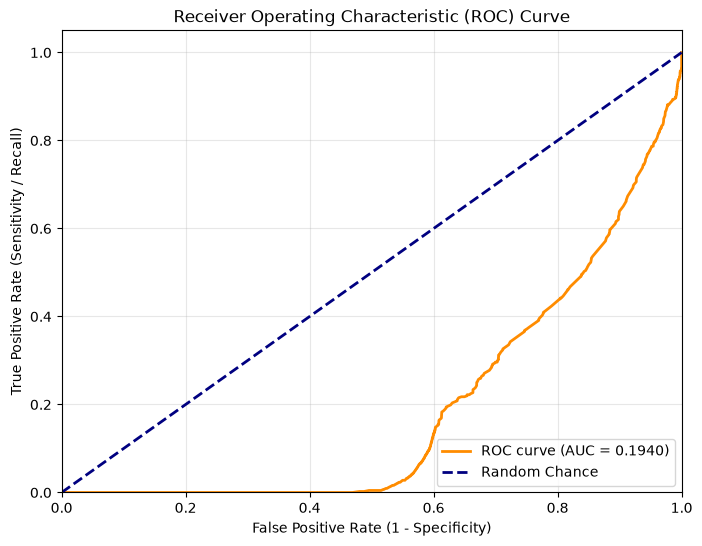

-----  Train  -----
Model F1 score: 0.0622
Model accuracy: 0.8347
[[33134  6391]
 [  213   219]]



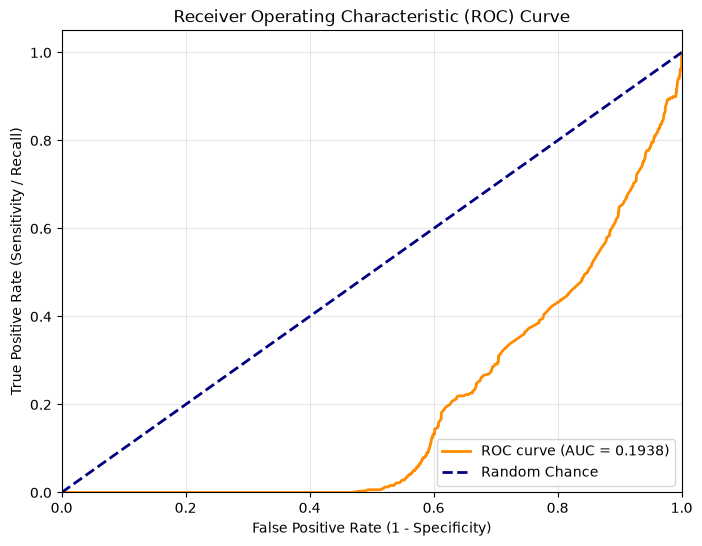

-----  Val  -----
Model F1 score: 0.0628
Model accuracy: 0.8358
[[24881  4767]
 [  154   165]]



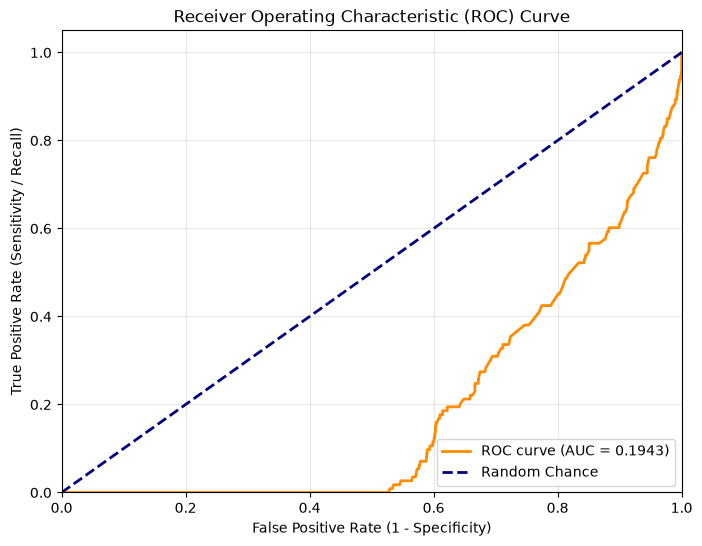

-----  Test  -----
Model F1 score: 0.0603
Model accuracy: 0.8315
[[8253 1624]
 [  59   54]]

------------------------------------




c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


------------------------------------
LogReg
------------------------------------


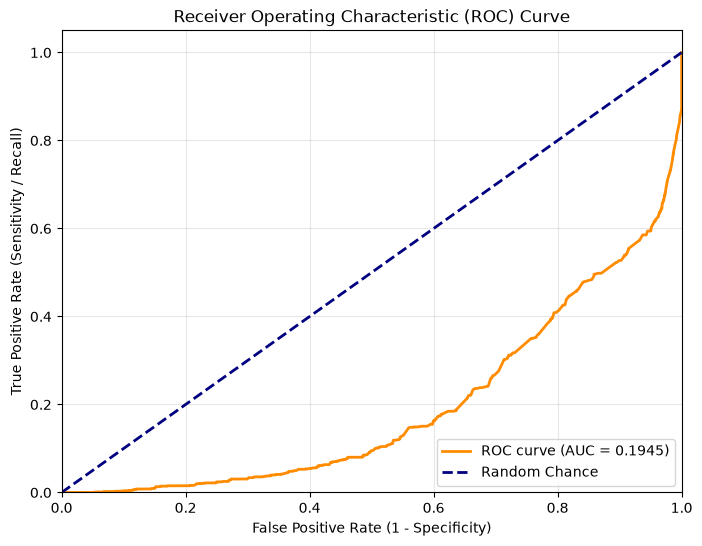

-----  Trainsm  -----
Model F1 score: 0.5961
Model accuracy: 0.6854
[[35826  3699]
 [21174 18351]]



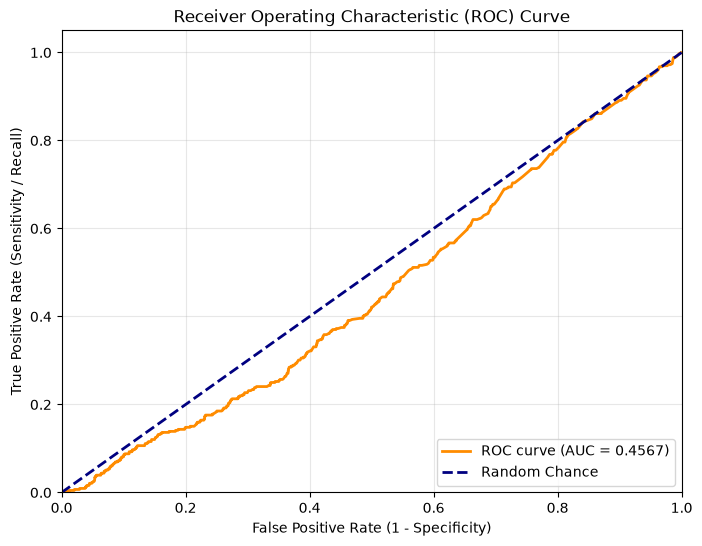

-----  Train  -----
Model F1 score: 0.0216
Model accuracy: 0.8977
[[35826  3699]
 [  387    45]]



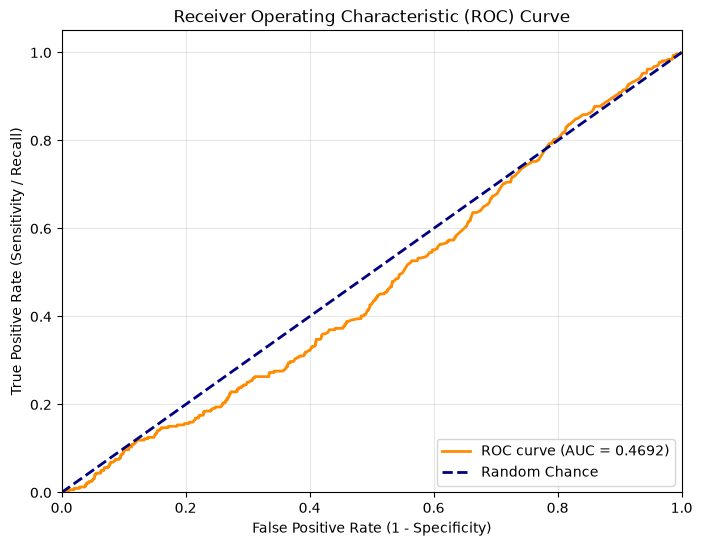

-----  Val  -----
Model F1 score: 0.0172
Model accuracy: 0.8971
[[26857  2791]
 [  292    27]]



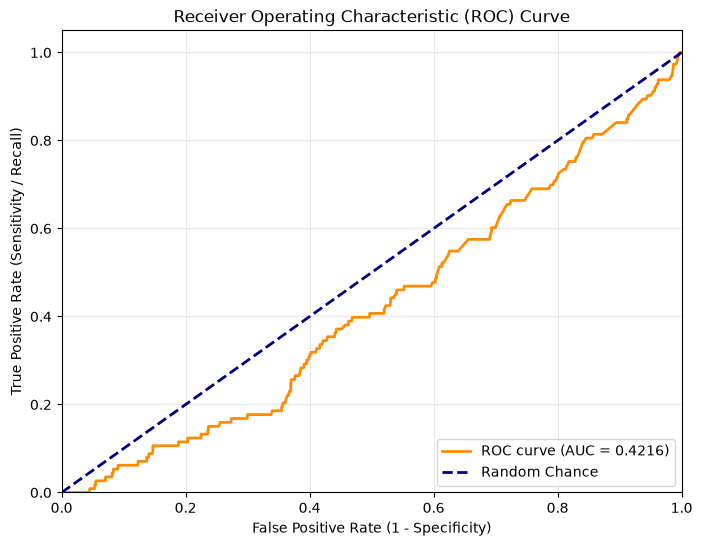

-----  Test  -----
Model F1 score: 0.0346
Model accuracy: 0.8996
[[8969  908]
 [  95   18]]

------------------------------------


------------------------------------
XGBoost - 
------------------------------------


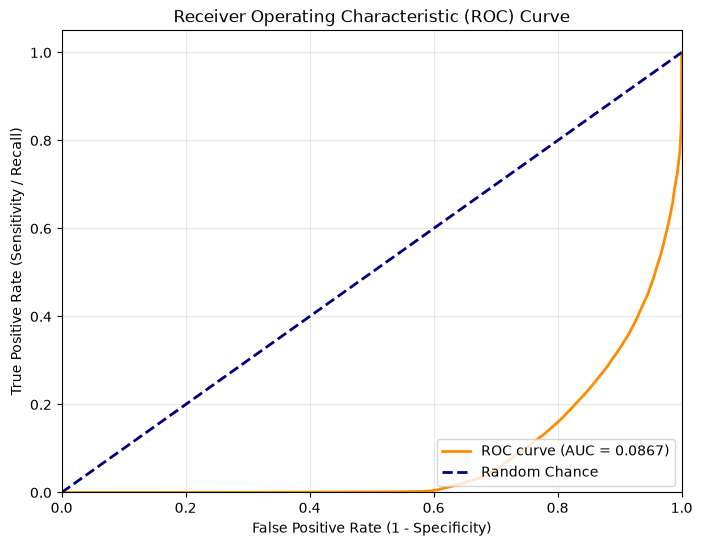

-----  Trainsm  -----
Model F1 score: 0.8040
Model accuracy: 0.8103
[[33301  6224]
 [ 8769 30756]]



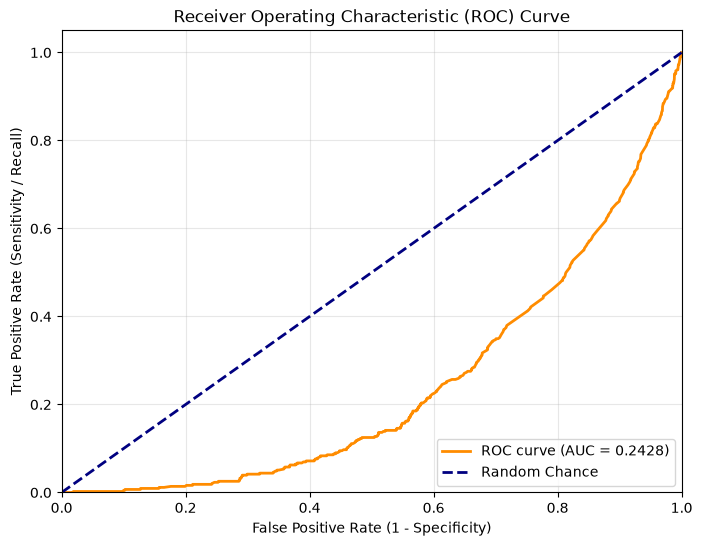

-----  Train  -----
Model F1 score: 0.0566
Model accuracy: 0.8383
[[33301  6224]
 [  238   194]]



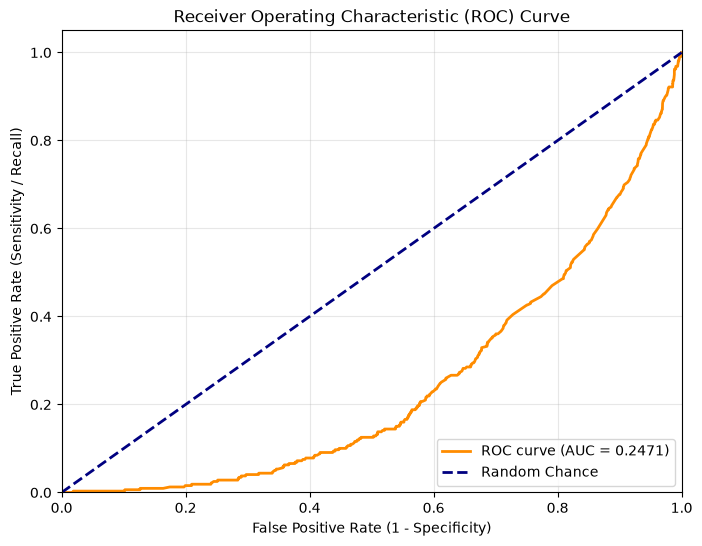

-----  Val  -----
Model F1 score: 0.0559
Model accuracy: 0.8389
[[24996  4652]
 [  176   143]]



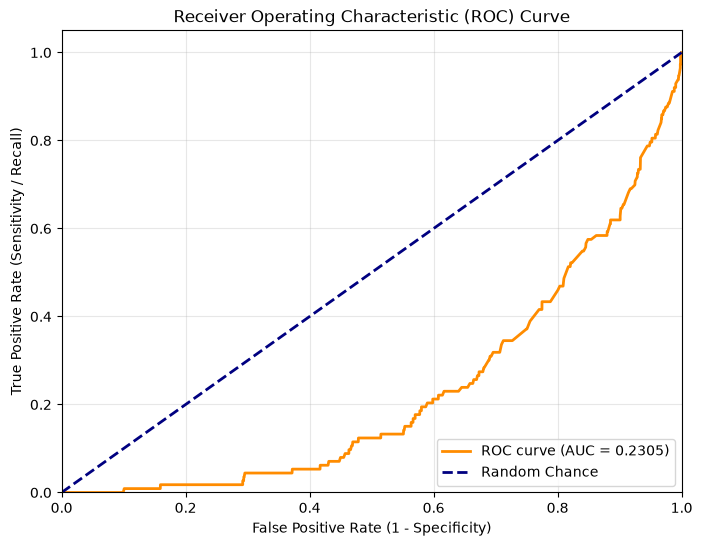

-----  Test  -----
Model F1 score: 0.0588
Model accuracy: 0.8364
[[8305 1572]
 [  62   51]]

------------------------------------




In [1266]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 0]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 0, 1)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [1267]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

,name,Trainsm_f1sore,Trainsm_acc,Trainsm_auc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,Train_acc,...,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_auc,Test_tn,Test_fp,Test_fn,Test_tp
4,RF - gini_300,0.809124,0.813801,0.084215,33134,6391,8328,31197,0.062198,0.834722,...,4767,154,165,0.060302,0.831532,0.194296,8253,1624,59,54
1,DT - entropy,0.809170,0.813827,0.084150,33131,6394,8323,31202,0.062172,0.834647,...,4767,154,165,0.060201,0.831231,0.189932,8250,1627,59,54
0,DT - gini,0.809170,0.813827,0.084150,33131,6394,8323,31202,0.062172,0.834647,...,4767,154,165,0.060201,0.831231,0.189932,8250,1627,59,54
6,XGBoost -,0.804026,0.810335,0.086684,33301,6224,8769,30756,0.056642,0.838276,...,4652,176,143,0.058756,0.836436,0.230472,8305,1572,62,51
3,RF - gini_100,0.809675,0.814067,0.084228,33088,6437,8261,31264,0.061521,0.833546,...,4798,154,165,0.058726,0.829930,0.195837,8238,1639,60,53
2,RF - gini_50,0.809660,0.814054,0.084239,33088,6437,8262,31263,0.061248,0.833521,...,4798,154,165,0.057650,0.829830,0.196416,8238,1639,61,52
5,LogReg,0.596054,0.685351,0.194529,35826,3699,21174,18351,0.021552,0.897740,...,2791,292,27,0.034649,0.899600,0.421606,8969,908,95,18


In [1268]:
import cvxopt as cvxopt 
import statsmodels.api as stm

model_stm = stm.Logit(y_train_sm, X_train_sm).fit_regularized(method='l1', maxiter=500, alpha=10.0,)

print(model_stm.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.6053331035276813
            Iterations: 408
            Function evaluations: 408
            Gradient evaluations: 408
                           Logit Regression Results                           
Dep. Variable:              churn_120   No. Observations:                79050
Model:                          Logit   Df Residuals:                    79018
Method:                           MLE   Df Model:                           31
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.1142
Time:                        00:04:19   Log-Likelihood:                -48537.
converged:                       True   LL-Null:                       -54793.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

----
----

## 150 days

## 150 days train_test dataset

In [1269]:
Data_train_150_df["state_income_level"] = Data_train_150_df.customer_state.map(prov_income_map)

Data_train_150_df["state_income_level_high"] = (Data_train_150_df["state_income_level"] == "high").astype(int)
Data_train_150_df["state_income_level_mid"] = (Data_train_150_df["state_income_level"] == "mid").astype(int)
Data_train_150_df["state_income_level_low"] = (Data_train_150_df["state_income_level"] == "low").astype(int)

Data_train_150_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,0.030705,6.0,brasilia,DF,delivered,1.0,credit_card,1.0,sports_leisure,0,low,0,0,1
1,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
2,008f3d5f45a11059239a5c452cd00006,309.90,0.086028,336.56,-28.0,5.0,0.059376,1.0,sao pedro da agua branca,MA,delivered,1.0,boleto,1.0,beauty,0,low,0,0,1
3,012e12f54f6e73b1faba89a119dab849,87.74,0.205152,105.74,-40.0,4.0,0.006207,10.0,maurilandia,GO,delivered,1.0,credit_card,5.0,household,0,low,0,0,1
4,01838e7d69d87bd8ff2b6ff06789adfb,126.90,0.253822,159.11,-35.0,5.0,0.035789,2.0,belem,PA,delivered,1.0,credit_card,1.0,fashion,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
14368,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,delivered,1.0,credit_card,1.0,sports_leisure,0,mid,0,1,0
14369,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00,0.320939,4134.84,-27.0,5.0,0.008290,1.0,sanharo,PE,delivered,1.0,credit_card,10.0,beauty,0,mid,0,1,0
14370,ffff371b4d645b6ecea244b27531430a,89.90,0.250945,112.46,-30.0,5.0,0.037600,5.0,sinop,MT,delivered,1.0,credit_card,1.0,automotive,0,low,0,0,1


In [1270]:
Data_train_150_df["high_review_score"] = (Data_train_150_df["review_score"]>= 4).astype(int)
Data_train_150_df["medium_review_score"] = ((Data_train_150_df["review_score"]< 4) & (Data_train_150_df["review_score"]>= 2)).astype(int)
Data_train_150_df["low_review_score"] = (Data_train_150_df["review_score"]< 2).astype(int)

Data_train_150_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,...,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,0.030705,6.0,brasilia,DF,...,1.0,sports_leisure,0,low,0,0,1,1,0,0
1,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,...,1.0,entertainment,0,high,1,0,0,1,0,0
2,008f3d5f45a11059239a5c452cd00006,309.90,0.086028,336.56,-28.0,5.0,0.059376,1.0,sao pedro da agua branca,MA,...,1.0,beauty,0,low,0,0,1,1,0,0
3,012e12f54f6e73b1faba89a119dab849,87.74,0.205152,105.74,-40.0,4.0,0.006207,10.0,maurilandia,GO,...,5.0,household,0,low,0,0,1,1,0,0
4,01838e7d69d87bd8ff2b6ff06789adfb,126.90,0.253822,159.11,-35.0,5.0,0.035789,2.0,belem,PA,...,1.0,fashion,0,low,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,...,3.0,household,0,high,1,0,0,1,0,0
14368,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,...,1.0,sports_leisure,0,mid,0,1,0,1,0,0
14369,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00,0.320939,4134.84,-27.0,5.0,0.008290,1.0,sanharo,PE,...,10.0,beauty,0,mid,0,1,0,1,0,0
14370,ffff371b4d645b6ecea244b27531430a,89.90,0.250945,112.46,-30.0,5.0,0.037600,5.0,sinop,MT,...,1.0,automotive,0,low,0,0,1,1,0,0


In [1271]:
Data_train_150_df["delay"] = (Data_train_150_df["dates_diff"]>0).astype(int)

Data_train_150_df["delay"]

0        0
1        0
2        0
3        0
4        0
        ..
14367    0
14368    0
14369    0
14370    0
14371    0
Name: delay, Length: 14372, dtype: int64

In [1272]:
Data_train_150_df["high_payment_value"] = (Data_train_150_df["payment_value"]>172.73).astype(int)

Data_train_150_df["high_payment_value"]

0        0
1        0
2        1
3        0
4        0
        ..
14367    0
14368    0
14369    1
14370    0
14371    0
Name: high_payment_value, Length: 14372, dtype: int64

In [1273]:
Data_train_150_df["expensive_freight"] = (Data_train_150_df["freight_to_weight_ratio"]>0.15).astype(int)

Data_train_150_df["expensive_freight"]

0        0
1        0
2        0
3        0
4        0
        ..
14367    0
14368    0
14369    0
14370    0
14371    0
Name: expensive_freight, Length: 14372, dtype: int64

In [1274]:
Data_train_150_df["high_freight_to_weight"] = (Data_train_150_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_train_150_df["high_freight_to_weight"]

0        0
1        0
2        0
3        0
4        0
        ..
14367    0
14368    0
14369    0
14370    0
14371    0
Name: high_freight_to_weight, Length: 14372, dtype: int64

In [1275]:
Data_train_150_df["is_high_price"] = (Data_train_150_df["price"]>120.64).astype(int)

Data_train_150_df["is_high_price"]

0        0
1        1
2        1
3        0
4        1
        ..
14367    0
14368    0
14369    1
14370    0
14371    0
Name: is_high_price, Length: 14372, dtype: int64

In [1276]:
Data_train_150_df["beyond_one year"] = (Data_train_150_df["payment_installments"] > 12.0).astype(int)

Data_train_150_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
14367    0
14368    0
14369    0
14370    0
14371    0
Name: beyond_one year, Length: 14372, dtype: int64

In [1277]:
Data_train_150_df["multiple_payment_methods"] = (Data_train_150_df["payment_sequential"] > 2.0).astype(int)

Data_train_150_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
14367    0
14368    0
14369    0
14370    0
14371    0
Name: multiple_payment_methods, Length: 14372, dtype: int64

In [1278]:
Data_train_150_df["low_foto_count"] = (Data_train_150_df["product_photos_qty"] < 2).astype(int)

Data_train_150_df["low_foto_count"]

0        0
1        1
2        1
3        0
4        0
        ..
14367    1
14368    1
14369    1
14370    0
14371    0
Name: low_foto_count, Length: 14372, dtype: int64

In [1279]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop= "first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_150_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [1280]:
encoded_array = col_trans.transform(Data_train_150_df)

In [1281]:
encoded_150_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_150_df.columns))

encoded_150_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__high_freight_to_weight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods,remainder__low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
14368,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
14369,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
14370,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [1282]:
encoded_150_df.columns = encoded_150_df.columns.str.replace('remainder__', '')

encoded_150_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,high_freight_to_weight,is_high_price,beyond_one year,multiple_payment_methods,low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14367,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
14368,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
14369,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
14370,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


----

## Test dataset

In [1283]:
Data_test_150_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,0.004327,3.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0
1,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,0.024633,6.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0
2,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
3,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0
4,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,0.005714,1.0,cachoeiras de macacu,RJ,delivered,1.0,debit_card,1.0,household,0
32715,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,0.071174,1.0,veranopolis,RS,delivered,1.0,boleto,1.0,beauty,0
32716,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,0.052343,0.0,fortaleza,CE,delivered,1.0,credit_card,2.0,unknown,0
32717,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [1284]:
Data_test_150_df["state_income_level"] = Data_test_150_df.customer_state.map(prov_income_map)

Data_test_150_df["state_income_level_high"] = (Data_test_150_df["state_income_level"] == "high").astype(int)
Data_test_150_df["state_income_level_mid"] = (Data_test_150_df["state_income_level"] == "mid").astype(int)
Data_test_150_df["state_income_level_low"] = (Data_test_150_df["state_income_level"] == "low").astype(int)

Data_test_150_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,0.004327,3.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0,high,1,0,0
1,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,0.024633,6.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0,high,1,0,0
2,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
3,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0,low,0,0,1
4,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,0.005714,1.0,cachoeiras de macacu,RJ,delivered,1.0,debit_card,1.0,household,0,high,1,0,0
32715,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,0.071174,1.0,veranopolis,RS,delivered,1.0,boleto,1.0,beauty,0,low,0,0,1
32716,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,0.052343,0.0,fortaleza,CE,delivered,1.0,credit_card,2.0,unknown,0,mid,0,1,0
32717,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [1285]:
Data_test_150_df["high_review_score"] = (Data_test_150_df["review_score"]>= 4).astype(int)
Data_test_150_df["medium_review_score"] = ((Data_test_150_df["review_score"]< 4) & (Data_test_150_df["review_score"]>= 2)).astype(int)
Data_test_150_df["low_review_score"] = (Data_test_150_df["review_score"]< 2).astype(int)

Data_test_150_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,...,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,0.004327,3.0,sao paulo,SP,...,8.0,miscellaneous,0,high,1,0,0,1,0,0
1,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,0.024633,6.0,campinas,SP,...,1.0,electronics,0,high,1,0,0,1,0,0
2,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,...,3.0,sports_leisure,0,low,0,0,1,0,0,1
3,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,0.021884,1.0,sao luis,MA,...,4.0,sports_leisure,0,low,0,0,1,0,0,1
4,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,0.030467,2.0,campinas,SP,...,3.0,household,0,high,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,0.005714,1.0,cachoeiras de macacu,RJ,...,1.0,household,0,high,1,0,0,1,0,0
32715,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,0.071174,1.0,veranopolis,RS,...,1.0,beauty,0,low,0,0,1,1,0,0
32716,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,0.052343,0.0,fortaleza,CE,...,2.0,unknown,0,mid,0,1,0,1,0,0
32717,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,...,3.0,beauty,0,high,1,0,0,0,0,1


In [1286]:
Data_test_150_df["delay"] = (Data_test_150_df["dates_diff"]>0).astype(int)

Data_test_150_df["delay"]

0        0
1        0
2        0
3        1
4        0
        ..
32714    0
32715    0
32716    0
32717    0
32718    0
Name: delay, Length: 32719, dtype: int64

In [1287]:
Data_test_150_df["high_payment_value"] = (Data_test_150_df["payment_value"]>172.73).astype(int)

Data_test_150_df["high_payment_value"]

0        0
1        0
2        1
3        0
4        0
        ..
32714    1
32715    0
32716    0
32717    1
32718    0
Name: high_payment_value, Length: 32719, dtype: int64

In [1288]:
Data_test_150_df["expensive_freight"] = (Data_test_150_df["freight_to_weight_ratio"]>20.03).astype(int)

Data_test_150_df["expensive_freight"]

0        0
1        0
2        0
3        0
4        0
        ..
32714    0
32715    0
32716    0
32717    0
32718    0
Name: expensive_freight, Length: 32719, dtype: int64

In [1289]:
Data_test_150_df["high_freight_to_weight"] = (Data_test_150_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_test_150_df["high_freight_to_weight"]

0        0
1        0
2        0
3        0
4        0
        ..
32714    0
32715    0
32716    0
32717    0
32718    0
Name: high_freight_to_weight, Length: 32719, dtype: int64

In [1290]:
Data_test_150_df["is_high_price"] = (Data_test_150_df["price"]>120.64).astype(int)

Data_test_150_df["is_high_price"]

0        1
1        0
2        1
3        0
4        0
        ..
32714    1
32715    0
32716    1
32717    1
32718    0
Name: is_high_price, Length: 32719, dtype: int64

In [1291]:
Data_test_150_df["beyond_one year"] = (Data_test_150_df["payment_installments"] > 12.0).astype(int)

Data_test_150_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
32714    0
32715    0
32716    0
32717    0
32718    0
Name: beyond_one year, Length: 32719, dtype: int64

In [1292]:
Data_test_150_df["multiple_payment_methods"] = (Data_test_150_df["payment_sequential"] > 2.0).astype(int)

Data_test_150_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
32714    0
32715    0
32716    0
32717    0
32718    0
Name: multiple_payment_methods, Length: 32719, dtype: int64

In [1293]:
Data_test_150_df["low_foto_count"] = (Data_test_150_df["product_photos_qty"] < 2).astype(int)

Data_test_150_df["low_foto_count"]

0        0
1        0
2        1
3        1
4        0
        ..
32714    1
32715    1
32716    1
32717    0
32718    0
Name: low_foto_count, Length: 32719, dtype: int64

In [1294]:
encoded_array_test = col_trans.transform(Data_test_150_df)

In [1295]:
encoded_150_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_150_df.columns))

encoded_150_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__high_freight_to_weight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods,remainder__low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
32715,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
32716,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
32717,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,0


In [1296]:
encoded_150_test_df.columns = encoded_150_test_df.columns.str.replace('remainder__', '')

encoded_150_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,high_freight_to_weight,is_high_price,beyond_one year,multiple_payment_methods,low_foto_count
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,1
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32714,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
32715,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
32716,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,1
32717,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,1,0,0,1,0,0,0


-----

## Train test split

In [1297]:
X_train = encoded_150_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score" ])

y_train = encoded_150_df['churn_150'].fillna(0).astype(int)

In [1298]:
X_valtest = encoded_150_test_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_150_test_df['churn_150'].fillna(0).astype(int)

In [1299]:
X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, random_state = 42)

In [1300]:
print(X_train.shape)
print(X_valtest.shape)

(14372, 38)
(32719, 38)


In [1301]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

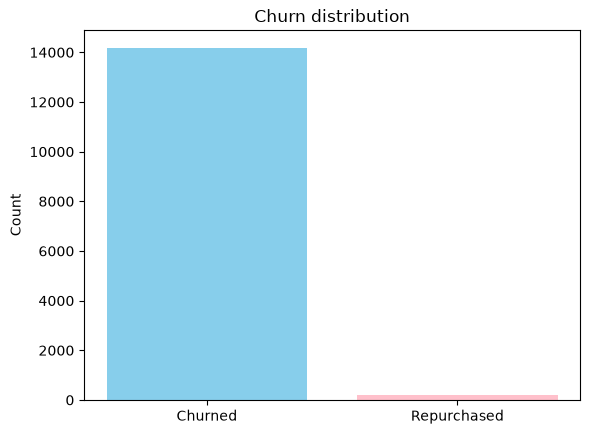

In [1302]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

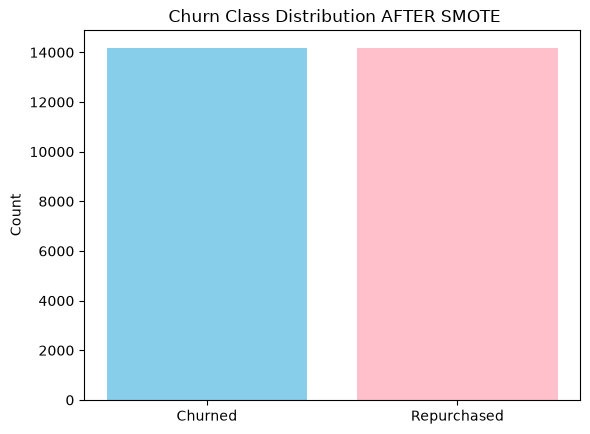

In [1303]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

------------------------------------
DT - gini
------------------------------------


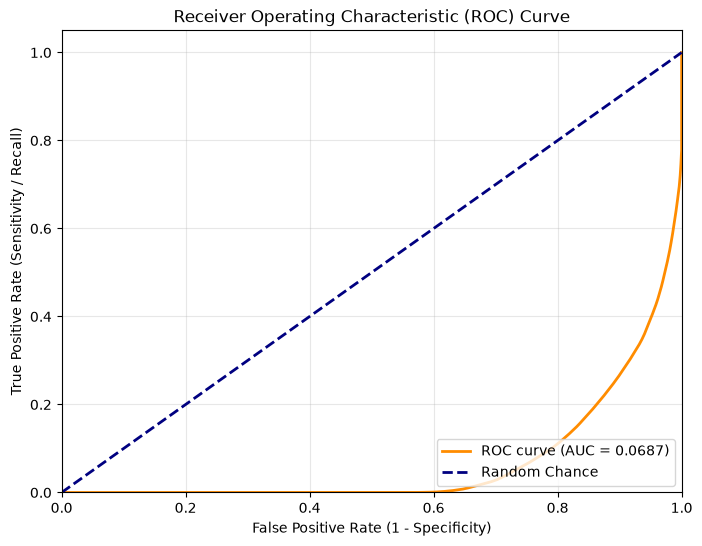

-----  Trainsm  -----
Model F1 score: 0.8398
Model accuracy: 0.8393
[[11854  2323]
 [ 2233 11944]]



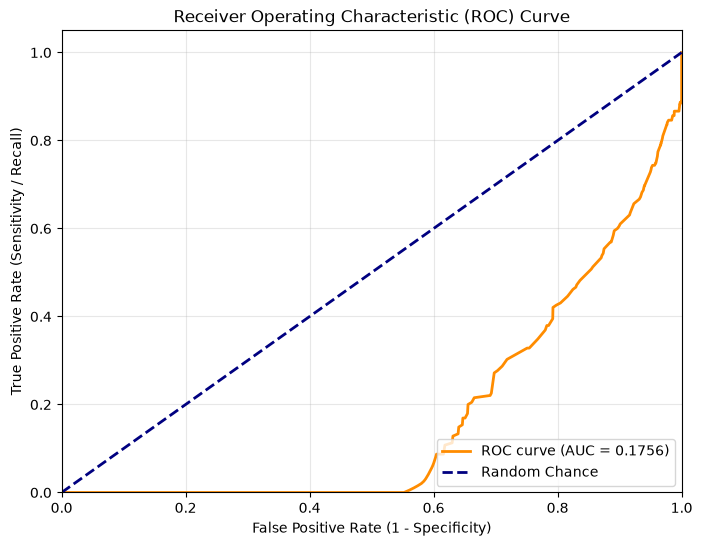

-----  Train  -----
Model F1 score: 0.0771
Model accuracy: 0.8318
[[11854  2323]
 [   94   101]]



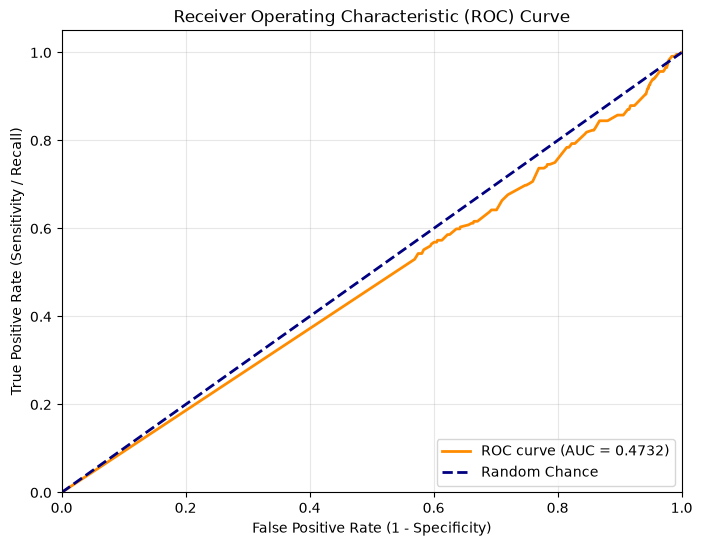

-----  Val  -----
Model F1 score: 0.0214
Model accuracy: 0.8250
[[20198  4109]
 [  185    47]]



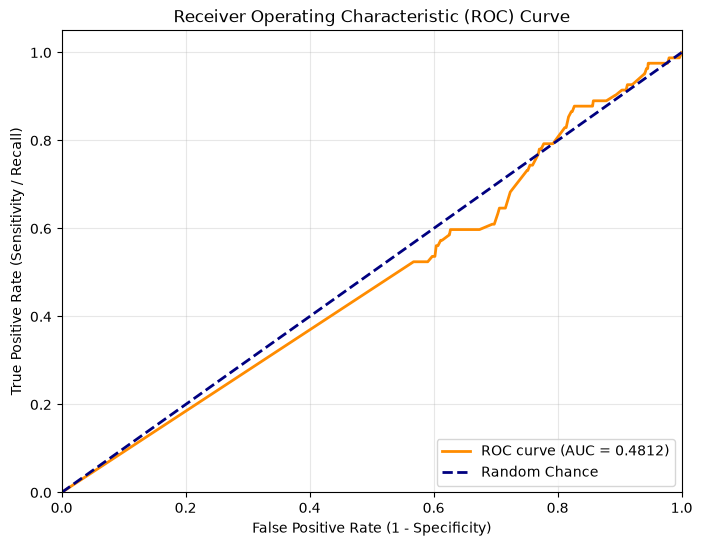

-----  Test  -----
Model F1 score: 0.0134
Model accuracy: 0.8199
[[6697 1401]
 [  72   10]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


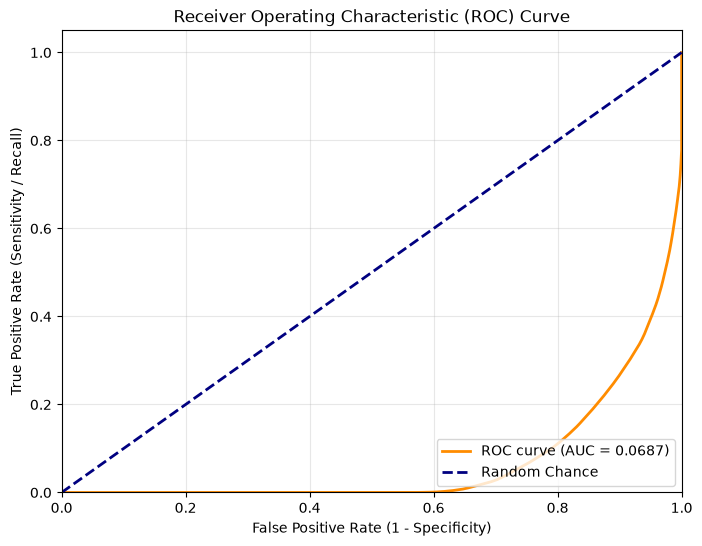

-----  Trainsm  -----
Model F1 score: 0.8398
Model accuracy: 0.8393
[[11854  2323]
 [ 2233 11944]]



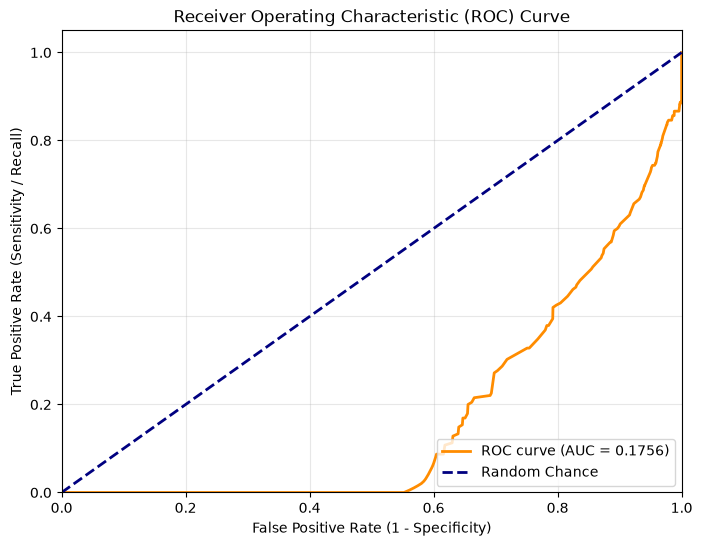

-----  Train  -----
Model F1 score: 0.0771
Model accuracy: 0.8318
[[11854  2323]
 [   94   101]]



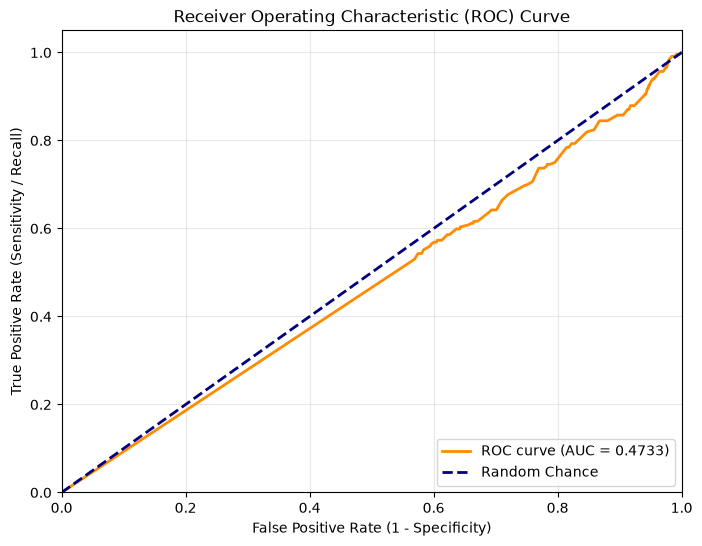

-----  Val  -----
Model F1 score: 0.0214
Model accuracy: 0.8248
[[20192  4115]
 [  185    47]]



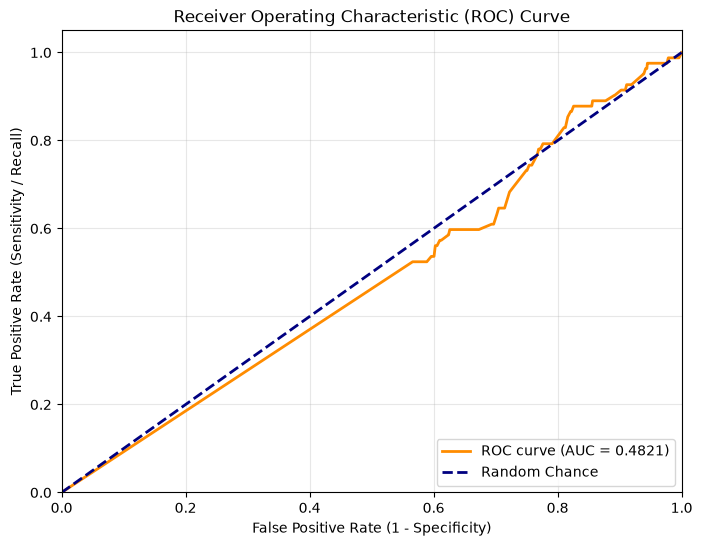

-----  Test  -----
Model F1 score: 0.0133
Model accuracy: 0.8187
[[6687 1411]
 [  72   10]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


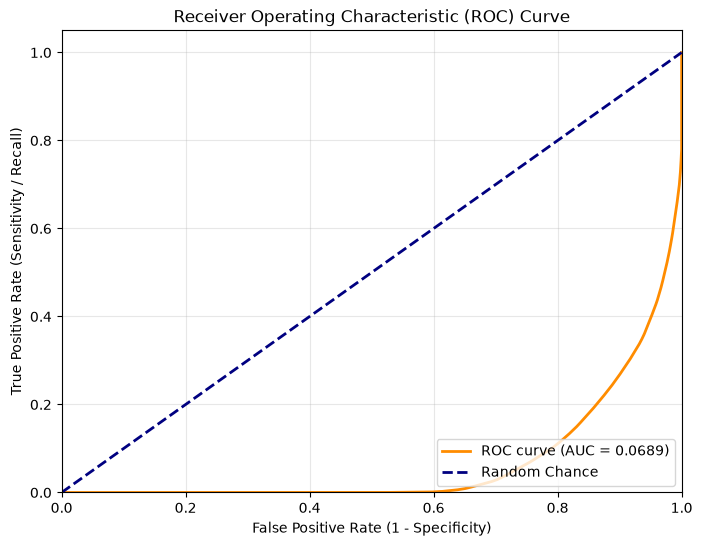

-----  Trainsm  -----
Model F1 score: 0.8420
Model accuracy: 0.8405
[[11778  2399]
 [ 2124 12053]]



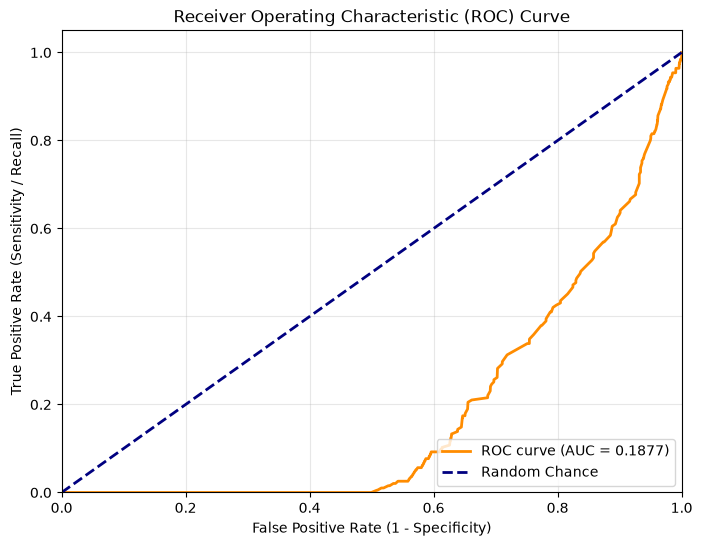

-----  Train  -----
Model F1 score: 0.0742
Model accuracy: 0.8265
[[11778  2399]
 [   95   100]]



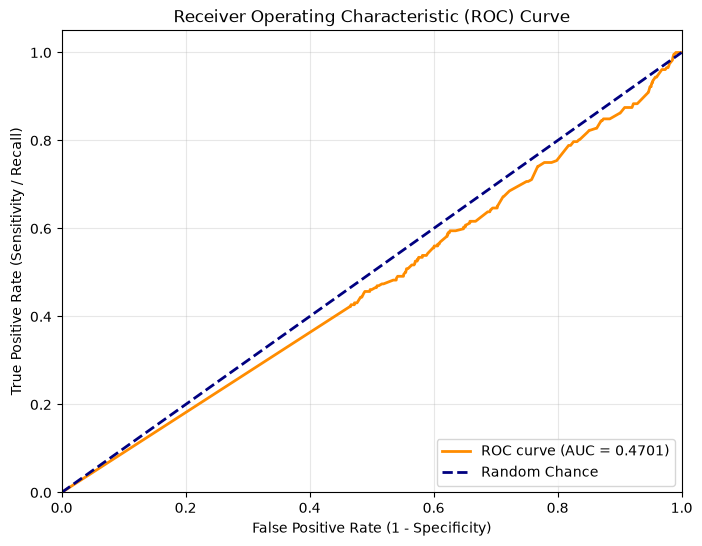

-----  Val  -----
Model F1 score: 0.0215
Model accuracy: 0.8253
[[20205  4102]
 [  185    47]]



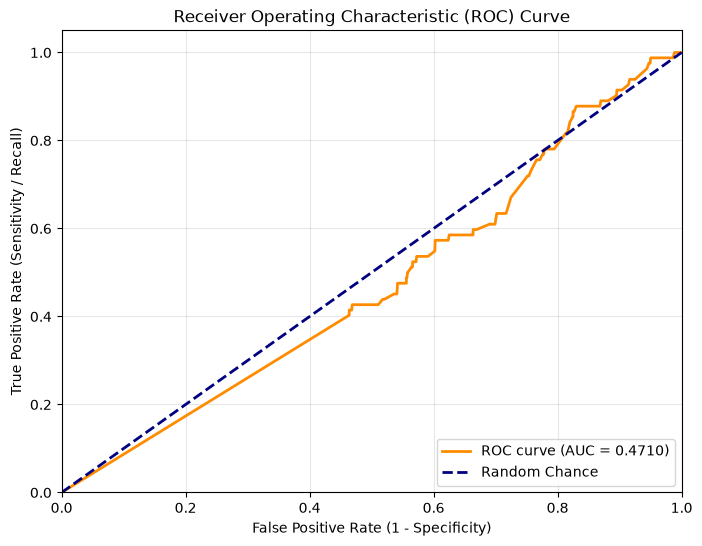

-----  Test  -----
Model F1 score: 0.0147
Model accuracy: 0.8194
[[6692 1406]
 [  71   11]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


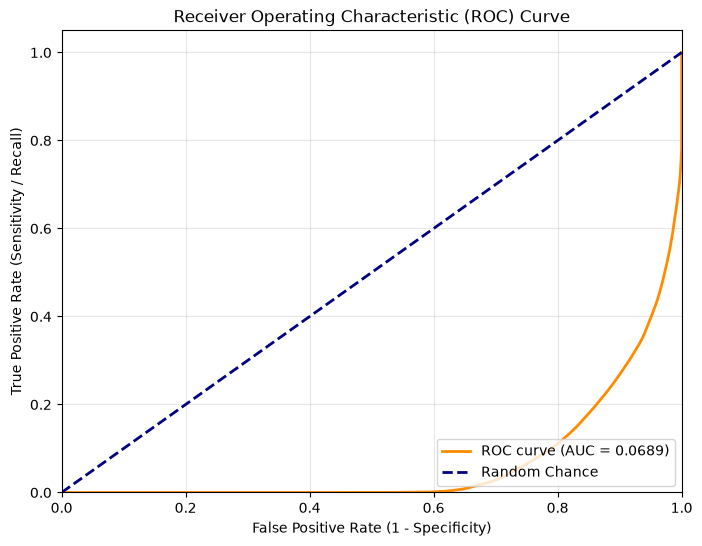

-----  Trainsm  -----
Model F1 score: 0.8397
Model accuracy: 0.8392
[[11854  2323]
 [ 2235 11942]]



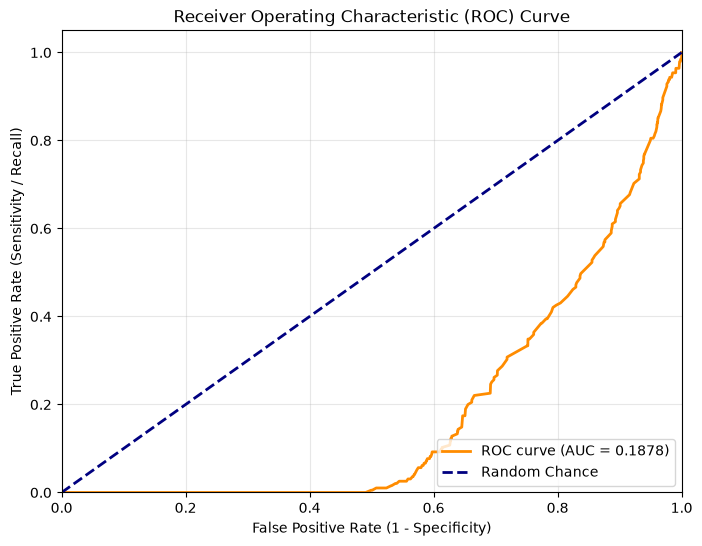

-----  Train  -----
Model F1 score: 0.0757
Model accuracy: 0.8317
[[11854  2323]
 [   96    99]]



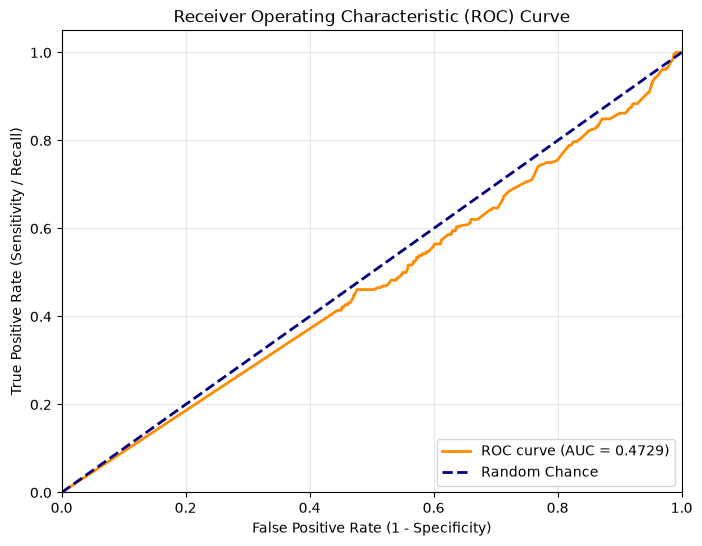

-----  Val  -----
Model F1 score: 0.0213
Model accuracy: 0.8281
[[20274  4033]
 [  186    46]]



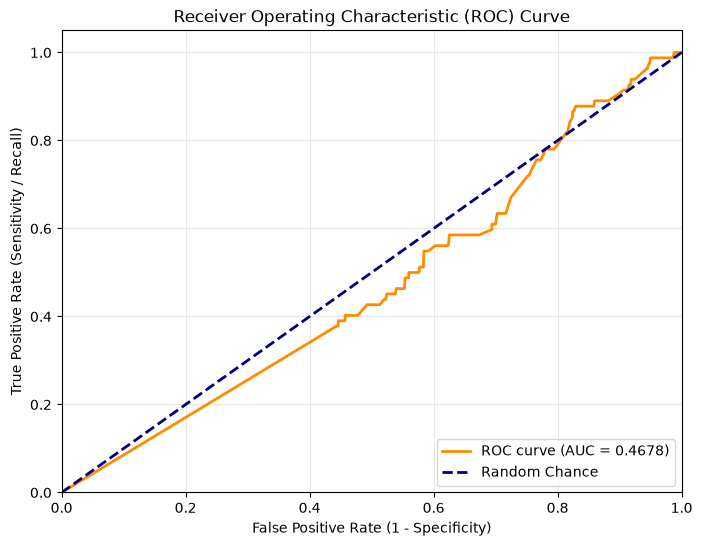

-----  Test  -----
Model F1 score: 0.0136
Model accuracy: 0.8222
[[6716 1382]
 [  72   10]]

------------------------------------


------------------------------------
RF - gini_300
------------------------------------


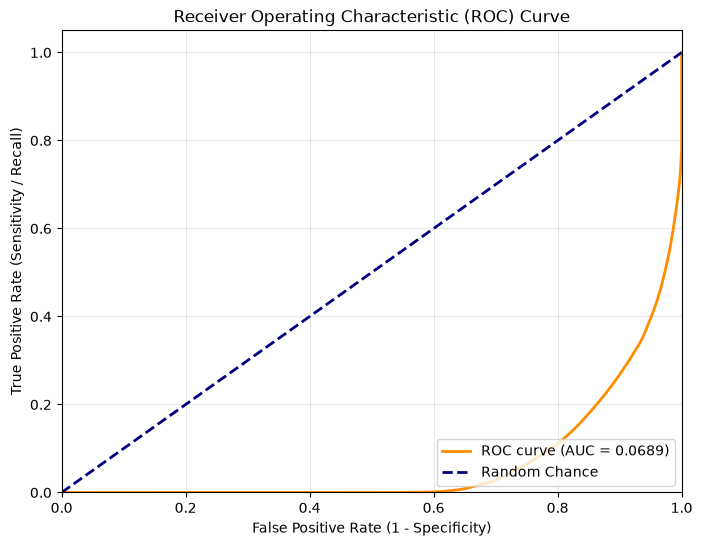

-----  Trainsm  -----
Model F1 score: 0.8398
Model accuracy: 0.8393
[[11854  2323]
 [ 2234 11943]]



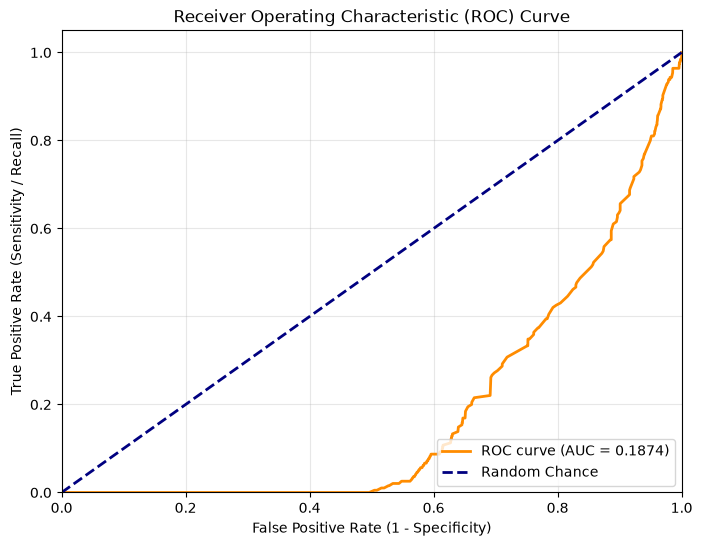

-----  Train  -----
Model F1 score: 0.0764
Model accuracy: 0.8318
[[11854  2323]
 [   95   100]]



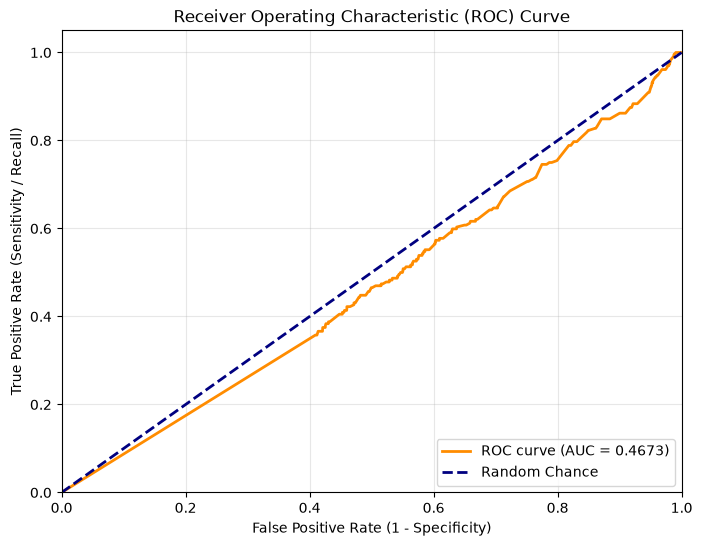

-----  Val  -----
Model F1 score: 0.0213
Model accuracy: 0.8281
[[20274  4033]
 [  186    46]]



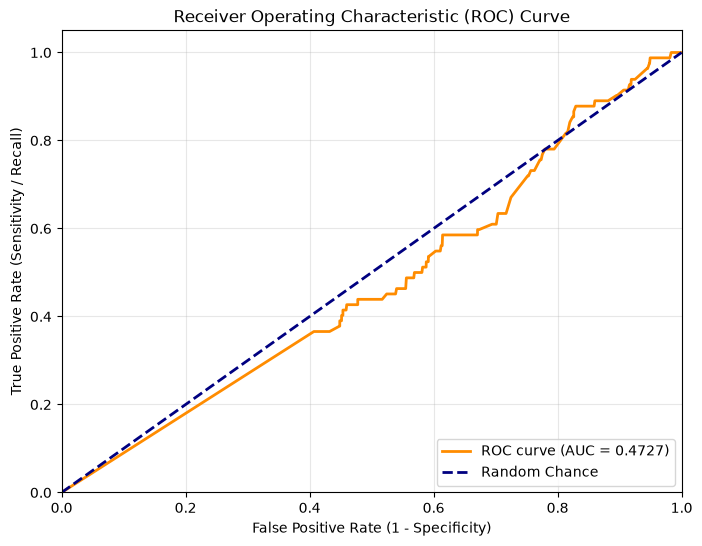

-----  Test  -----
Model F1 score: 0.0136
Model accuracy: 0.8222
[[6716 1382]
 [  72   10]]

------------------------------------




c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


------------------------------------
LogReg
------------------------------------


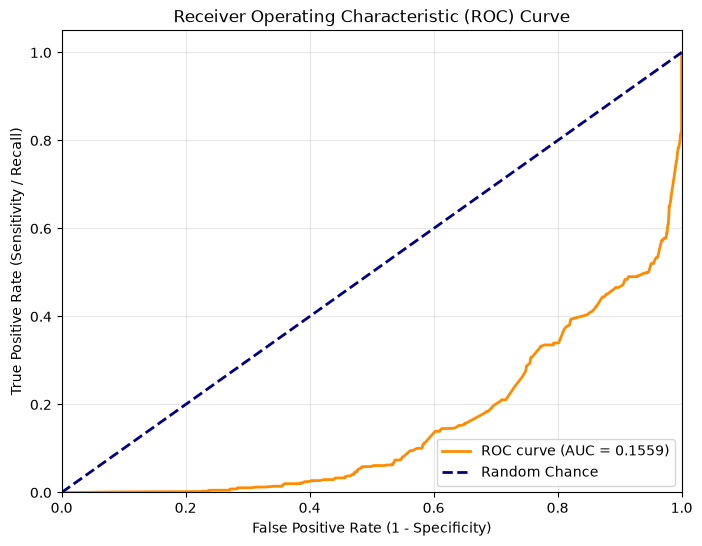

-----  Trainsm  -----
Model F1 score: 0.6387
Model accuracy: 0.7119
[[12963  1214]
 [ 6955  7222]]



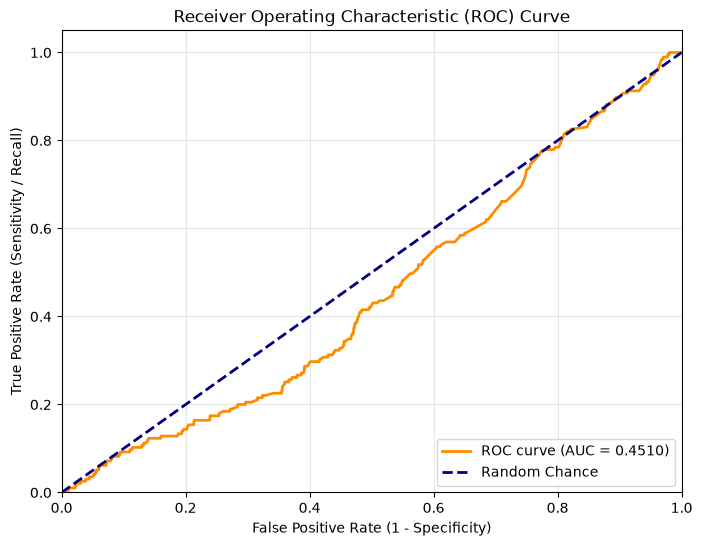

-----  Train  -----
Model F1 score: 0.0238
Model accuracy: 0.9031
[[12963  1214]
 [  178    17]]



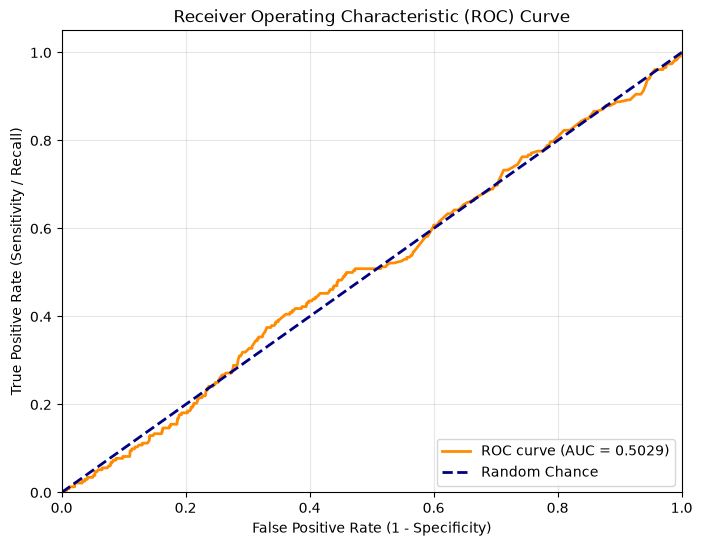

-----  Val  -----
Model F1 score: 0.0192
Model accuracy: 0.8919
[[21860  2447]
 [  206    26]]



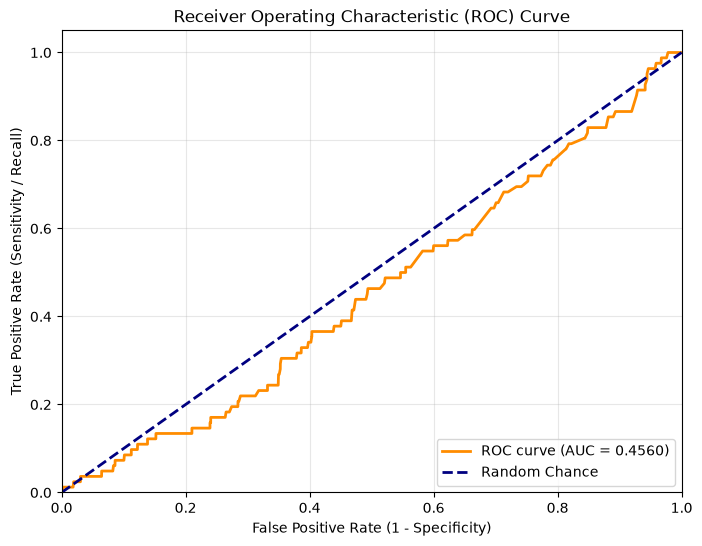

-----  Test  -----
Model F1 score: 0.0248
Model accuracy: 0.8943
[[7304  794]
 [  71   11]]

------------------------------------


------------------------------------
XGBoost - 
------------------------------------


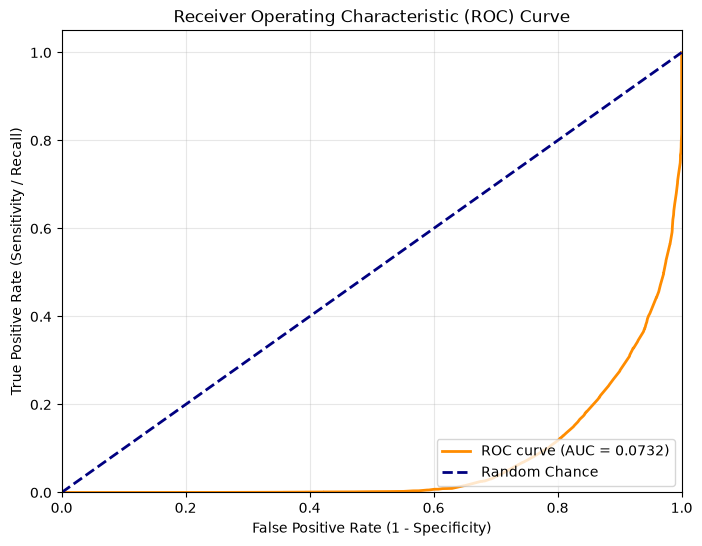

-----  Trainsm  -----
Model F1 score: 0.8313
Model accuracy: 0.8330
[[11959  2218]
 [ 2516 11661]]



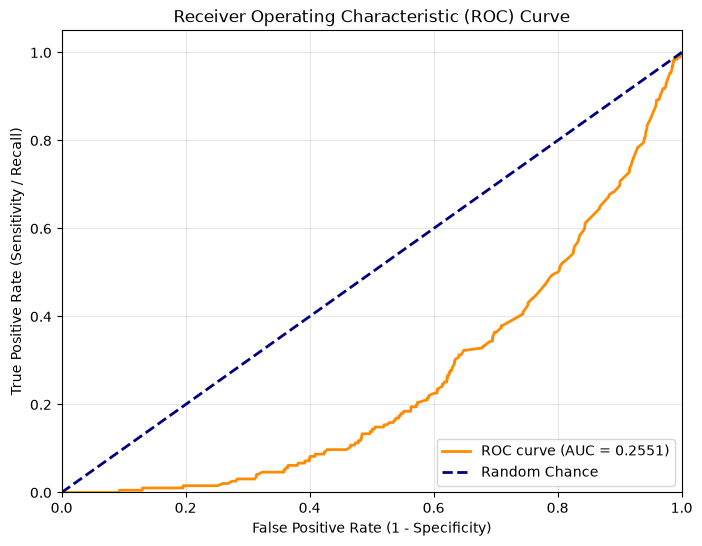

-----  Train  -----
Model F1 score: 0.0626
Model accuracy: 0.8375
[[11959  2218]
 [  117    78]]



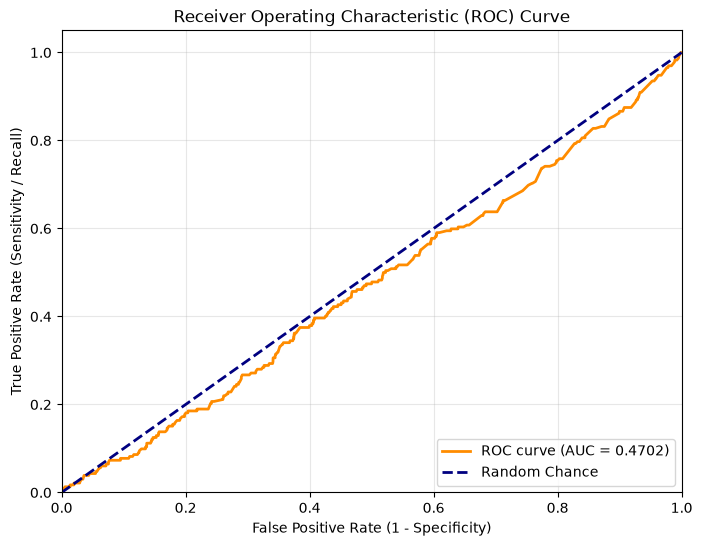

-----  Val  -----
Model F1 score: 0.0217
Model accuracy: 0.8350
[[20444  3863]
 [  187    45]]



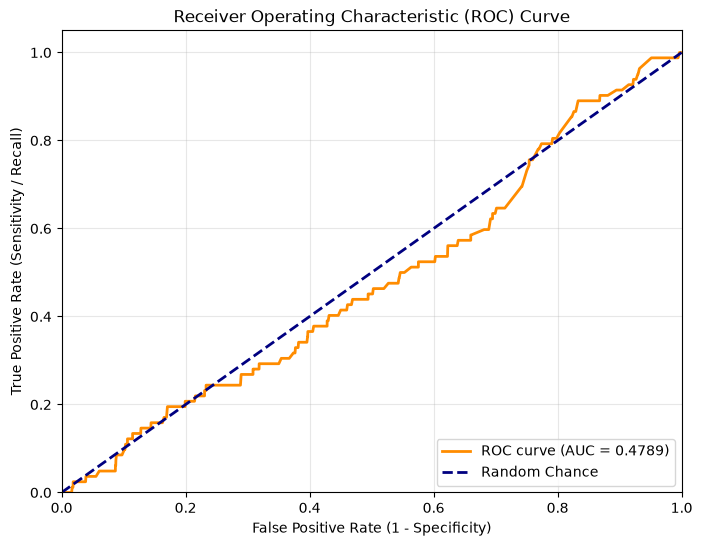

-----  Test  -----
Model F1 score: 0.0126
Model accuracy: 0.8270
[[6756 1342]
 [  73    9]]

------------------------------------




In [1304]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 0]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 0, 1)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [1305]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

,name,Trainsm_f1sore,Trainsm_acc,Trainsm_auc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,Train_acc,...,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_auc,Test_tn,Test_fp,Test_fn,Test_tp
5,LogReg,0.638748,0.711893,0.155927,12963,1214,6955,7222,0.023843,0.903145,...,2447,206,26,0.024803,0.894254,0.456038,7304,794,71,11
2,RF - gini_50,0.842013,0.840481,0.068897,11778,2399,2124,12053,0.074239,0.826468,...,4102,185,47,0.014676,0.819438,0.470975,6692,1406,71,11
3,RF - gini_100,0.839744,0.839247,0.068887,11854,2323,2235,11942,0.075659,0.831687,...,4033,186,46,0.013569,0.822249,0.467802,6716,1382,72,10
4,RF - gini_300,0.839785,0.839282,0.068867,11854,2323,2234,11943,0.076394,0.831756,...,4033,186,46,0.013569,0.822249,0.472730,6716,1382,72,10
0,DT - gini,0.839826,0.839317,0.068705,11854,2323,2233,11944,0.077129,0.831826,...,4109,185,47,0.013396,0.819927,0.481161,6697,1401,72,10
1,DT - entropy,0.839826,0.839317,0.068705,11854,2323,2233,11944,0.077129,0.831826,...,4115,185,47,0.013307,0.818704,0.482136,6687,1411,72,10
6,XGBoost -,0.831266,0.833039,0.073151,11959,2218,2516,11661,0.062625,0.837531,...,3863,187,45,0.012561,0.827017,0.478939,6756,1342,73,9


In [1306]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train_sm, X_train_sm).fit()

print(model_stm.summary())

         Current function value: 0.540316
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:              churn_150   No. Observations:                28354
Model:                          Logit   Df Residuals:                    28316
Method:                           MLE   Df Model:                           37
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.2205
Time:                        00:04:38   Log-Likelihood:                -15320.
converged:                      False   LL-Null:                       -19653.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                 0.8798      0.365      2.409      0.016      

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


------
------